# AI Resume Analyzer: Explicit & Implicit Skill Gap Identification
## Benchmarking Pretrained Transformers (SBERT, BERT, RoBERTa, DistilBERT, MPNet) and Proposed Hybrid Model with ESCO Taxonomy

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)
![Python 3.10+](https://img.shields.io/badge/Python-3.10%2B-blue.svg)
![PyTorch](https://img.shields.io/badge/PyTorch-2.0%2B-ee4c2c.svg)
![Hugging Face](https://img.shields.io/badge/HuggingFace-Transformers-yellow.svg)
![Taxonomy](https://img.shields.io/badge/Taxonomy-ESCO%20v1.1-green.svg)
![License](https://img.shields.io/badge/License-MIT-purple.svg)



In [ ]:
# Step 1: Install Required Dependencies
# Designed for Google Colab and local Python environments
!pip install -q --upgrade pypdf reportlab sentence-transformers transformers torch scikit-learn matplotlib seaborn pandas numpy tabulate

print("[OK] All dependencies installed successfully.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.1/553.1 MB 870.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Step 2: System Imports, Deterministic Seeds, and Visual Configuration

# ============================================================
# 1. Install Required Dependencies
# ============================================================
import sys
import subprocess

required_packages = [
    "pypdf",
    "reportlab",
    "sentence-transformers",
    "transformers",
    "torch",
    "seaborn",
    "tabulate"
]

for package in required_packages:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        package
    ])

# ============================================================
# 2. System Imports
# ============================================================
import os
import re
import sys
import time
import json
import random
import warnings

from typing import List, Dict, Tuple, Set, Optional, Any
from dataclasses import dataclass, field

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    auc
)

from sklearn.metrics.pairwise import cosine_similarity
from tabulate import tabulate

import torch
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer

# PDF processing
from pypdf import PdfReader

# PDF report generation
from reportlab.lib.pagesizes import letter
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    HRFlowable,
    Table,
    TableStyle
)
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors

# ============================================================
# 3. Warning Configuration
# ============================================================
warnings.filterwarnings("ignore")

# ============================================================
# 4. Deterministic Seeds
# ============================================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ============================================================
# 5. Device Configuration
# ============================================================
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"[Device Configuration] Using computation device: {DEVICE}")

# ============================================================
# 6. Create Required Directories
# ============================================================
os.makedirs("./figures", exist_ok=True)
os.makedirs("./sample_resumes", exist_ok=True)
os.makedirs("./reports", exist_ok=True)

# ============================================================
# 7. Publication-Grade Visualization Configuration
# ============================================================
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": [
        "DejaVu Sans",
        "Arial",
        "Helvetica"
    ],

    "font.size": 11,

    "axes.titlesize": 13,
    "axes.labelsize": 12,

    "axes.titleweight": "bold",
    "axes.labelweight": "bold",

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 10,

    "figure.titlesize": 15,
    "figure.titleweight": "bold",

    "figure.dpi": 300,
    "savefig.dpi": 300,

    "savefig.bbox": "tight"
})

# ============================================================
# 8. Model Color Configuration
# ============================================================
MODEL_COLORS = {
    "Sentence-BERT": "#1f77b4",
    "BERT": "#ff7f0e",
    "RoBERTa": "#2ca02c",
    "DistilBERT": "#d62728",
    "MPNet": "#9467bd",
    "Proposed Hybrid": "#e377c2"
}

print("[OK] Environment configured successfully.")
print("[OK] Deterministic seed set to 42.")
print("[OK] Required packages installed/imported successfully.")

[Device Configuration] Using computation device: cuda
[OK] Environment configured successfully.
[OK] Deterministic seed set to 42.
[OK] Required packages installed/imported successfully.


---
## Section 1: Standardized ESCO Skill Taxonomy Engine & Dependency Knowledge Graph

### 1.1 ESCO Grounding
The **European Skills, Competences, Qualifications and Occupations (ESCO)** taxonomy represents the premier multilingual European classification system for labor market concepts. For Information and Communications Technology (ICT), ESCO categorizes technical capabilities into hierarchical clusters, eliminating ambiguity and mapping non-standard resume jargon into canonical definitions.

### 1.2 Mathematical Formulation of Implicit Skill Gaps
Let $\mathcal{S}_{\text{ESCO}}$ denote the standardized universe of technical skills.
We define a directed acyclic knowledge graph of skill prerequisites:
$$\mathcal{G}_{\text{prereq}} = (\mathcal{V}_{\text{ESCO}}, \mathcal{E}_{\text{prereq}})$$
where an edge $(u, v) \in \mathcal{E}_{\text{prereq}}$ signifies that mastering skill $u$ *implicitly requires or presupposes* competency in foundational skill $v$ ($u \succ v$).

Given a Job Description specifying a set of explicit technical requirements $\mathcal{S}_{\text{JD, explicit}} \subset \mathcal{V}_{\text{ESCO}}$, the **latent implicit requirements** $\mathcal{S}_{\text{JD, implicit}}$ are defined as:
$$\mathcal{S}_{\text{JD, implicit}} = \left( \bigcup_{s \in \mathcal{S}_{\text{JD, explicit}}} \text{Prerequisites}(s) \right) \setminus \mathcal{S}_{\text{JD, explicit}}$$
where $\text{Prerequisites}(s) = \{ v \in \mathcal{V}_{\text{ESCO}} \mid (s, v) \in \mathcal{E}_{\text{prereq}} \}$.

Let $\mathcal{S}_{\text{Resume}} \subset \mathcal{V}_{\text{ESCO}}$ be the candidate's verified skills extracted from their resume. We define:
1. **Matched Skills**:
   $$\mathcal{M} = \mathcal{S}_{\text{Resume}} \cap (\mathcal{S}_{\text{JD, explicit}} \cup \mathcal{S}_{\text{JD, implicit}})$$
2. **Explicit Skill Gaps**:
   $$\mathcal{G}_{\text{explicit}} = \mathcal{S}_{\text{JD, explicit}} \setminus \mathcal{S}_{\text{Resume}}$$
3. **Implicit Skill Gaps**:
   $$\mathcal{G}_{\text{implicit}} = \mathcal{S}_{\text{JD, implicit}} \setminus \mathcal{S}_{\text{Resume}}$$

This mathematical duality allows recruitment engines to differentiate between:
- A candidate missing an explicitly requested top-level tool (e.g. *Terraform*).
- A candidate possessing an advanced tool (e.g. *Kubernetes*) but lacking foundational operational competencies (e.g. *Linux Administration*, *Networking*, *Docker*).


In [3]:
# Step 3: Standardized ESCO ICT Taxonomy & Dependency Knowledge Graph

@dataclass
class ESCOSkill:
    preferred_label: str
    alt_labels: List[str]
    category: str
    description: str
    implicit_prerequisites: List[str] = field(default_factory=list)

class ESCOTaxonomyEngine:
    """
    Standardized ESCO Skill Taxonomy engine with alias normalization,
    contextual semantic definitions, and prerequisite dependency graph traversal.
    """
    def __init__(self):
        self.skills: Dict[str, ESCOSkill] = {}
        self.alias_to_canonical: Dict[str, str] = {}
        self._build_ict_taxonomy()

    def _add_skill(self, pref_label: str, alt_labels: List[str], category: str,
                   description: str, prereqs: List[str]):
        canonical = pref_label.strip()
        skill_obj = ESCOSkill(
            preferred_label=canonical,
            alt_labels=[a.strip() for a in alt_labels],
            category=category.strip(),
            description=description.strip(),
            implicit_prerequisites=[p.strip() for p in prereqs]
        )
        self.skills[canonical.lower()] = skill_obj
        # Map preferred label to itself
        self.alias_to_canonical[canonical.lower()] = canonical
        # Map all aliases
        for alt in alt_labels:
            self.alias_to_canonical[alt.strip().lower()] = canonical

    def _build_ict_taxonomy(self):
        """Constructs standardized ESCO ICT technical skills across 7 major clusters."""
        # 1. Programming Languages & Runtimes
        self._add_skill("Python", ["python3", "py", "cpython"], "Programming Languages",
                        "High-level general-purpose programming language emphasizing code readability, widely used in data science, AI, and web backend.",
                        ["Object-Oriented Programming", "Algorithmic Thinking"])
        self._add_skill("JavaScript", ["js", "es6", "ecmascript"], "Programming Languages",
                        "Dynamic scripting language for web client-side development and asynchronous runtime environments.",
                        ["Web Development Basics", "Algorithmic Thinking"])
        self._add_skill("TypeScript", ["ts"], "Programming Languages",
                        "Strictly typed syntactical superset of JavaScript adding static type definitions for large-scale application development.",
                        ["JavaScript", "Object-Oriented Programming"])
        self._add_skill("Java", ["java core", "jdk", "jvm"], "Programming Languages",
                        "Class-based object-oriented language running on the Java Virtual Machine for enterprise-grade applications.",
                        ["Object-Oriented Programming", "Memory Management Basics"])
        self._add_skill("Go", ["golang"], "Programming Languages",
                        "Statically typed, compiled programming language designed at Google for concurrent, scalable networking and cloud systems.",
                        ["Concurrency Patterns", "Systems Programming Basics"])
        self._add_skill("Rust", ["rustlang"], "Programming Languages",
                        "Systems programming language focused on memory safety, concurrency, and zero-cost abstractions without garbage collection.",
                        ["Memory Management Basics", "Systems Programming Basics"])
        self._add_skill("C++", ["cpp", "c plus plus"], "Programming Languages",
                        "High-performance compiled language supporting procedural, object-oriented, and generic programming paradigms.",
                        ["C", "Memory Management Basics", "Object-Oriented Programming"])
        self._add_skill("Bash/Shell", ["bash", "shell scripting", "sh", "zsh"], "Programming Languages",
                        "Command-line shell and scripting language for task automation and operating system interaction in Unix environments.",
                        ["Linux Administration"])

        # 2. Web & Frontend Frameworks
        self._add_skill("React", ["reactjs", "react.js"], "Web & Frontend Frameworks",
                        "Component-based JavaScript library for building declarative, interactive user interfaces with virtual DOM.",
                        ["JavaScript", "HTML5/CSS3", "State Management"])
        self._add_skill("Node.js", ["nodejs", "node"], "Web & Frontend Frameworks",
                        "Asynchronous event-driven JavaScript runtime built on Chrome's V8 engine for scalable network applications.",
                        ["JavaScript", "Asynchronous Programming", "RESTful API Design"])
        self._add_skill("FastAPI", ["fastapi framework"], "Web & Frontend Frameworks",
                        "Modern, high-performance web framework for building APIs with Python based on standard Python type hints.",
                        ["Python", "RESTful API Design", "Asynchronous Programming"])
        self._add_skill("Django", ["django framework"], "Web & Frontend Frameworks",
                        "High-level Python web framework that encourages rapid development and clean, pragmatic architectural design.",
                        ["Python", "Web Development Basics", "Relational Database Design"])
        self._add_skill("HTML5/CSS3", ["html", "css", "html5", "css3", "web styling"], "Web & Frontend Frameworks",
                        "Foundational markup and stylesheet standards structuring and formatting visual presentations on the World Wide Web.",
                        ["Web Development Basics"])
        self._add_skill("Next.js", ["nextjs"], "Web & Frontend Frameworks",
                        "Production React framework enabling server-side rendering, static site generation, and hybrid web applications.",
                        ["React", "JavaScript", "Node.js"])
        self._add_skill("State Management", ["redux", "zustand", "mobx", "state management patterns"], "Web & Frontend Frameworks",
                        "Architectural patterns and libraries for synchronizing application state across complex frontend component trees.",
                        ["JavaScript"])

        # 3. Cloud, Containers & DevOps
        self._add_skill("Kubernetes", ["k8s", "kubernetes cluster", "container orchestration"], "Cloud & DevOps",
                        "Open-source system for automating deployment, scaling, and operational management of containerized applications.",
                        ["Docker", "Linux Administration", "Container Networking", "CI/CD"])
        self._add_skill("Docker", ["docker containers", "containerization"], "Cloud & DevOps",
                        "Platform utilizing OS-level virtualization to deliver software packages in isolated, reproducible lightweight containers.",
                        ["Linux Administration", "Operating System Basics"])
        self._add_skill("AWS", ["amazon web services", "aws cloud"], "Cloud & DevOps",
                        "Comprehensive cloud computing platform offering compute, storage, networking, and managed serverless infrastructure.",
                        ["Cloud Computing Concepts", "Linux Administration", "Networking Fundamentals"])
        self._add_skill("Terraform", ["hashicorp terraform", "iac"], "Cloud & DevOps",
                        "Infrastructure as Code tool for building, changing, and versioning cloud and on-premises infrastructure safely.",
                        ["Cloud Computing Concepts", "DevOps Principles", "Infrastructure as Code"])
        self._add_skill("CI/CD", ["continuous integration", "continuous deployment", "github actions", "gitlab ci", "jenkins"], "Cloud & DevOps",
                        "Automated pipeline practices bridging software development, automated testing, artifact creation, and production release.",
                        ["Git Version Control", "Automated Testing", "DevOps Principles"])
        self._add_skill("Linux Administration", ["linux", "unix", "ubuntu", "rhel", "sysadmin"], "Cloud & DevOps",
                        "Configuring, maintaining, securing, and troubleshooting Unix-like server operating systems and process environments.",
                        ["Operating System Basics"])
        self._add_skill("Prometheus", ["prometheus monitoring"], "Cloud & DevOps",
                        "Systems monitoring and alerting toolkit collecting multi-dimensional time series metrics with PromQL.",
                        ["Linux Administration", "Observability Principles"])
        self._add_skill("Grafana", ["grafana dashboards"], "Cloud & DevOps",
                        "Multi-platform analytics and interactive data visualization web application for telemetry and metric visualization.",
                        ["Observability Principles"])

        # 4. Databases & Data Storage
        self._add_skill("PostgreSQL", ["postgres", "psql", "postgresql rdbms"], "Databases & Storage",
                        "Advanced open-source relational database management system supporting ACID compliance, complex queries, and JSON.",
                        ["SQL", "Relational Database Design", "Database Indexing"])
        self._add_skill("MongoDB", ["mongo", "mongodb nosql"], "Databases & Storage",
                        "Document-oriented NoSQL database program using JSON-like documents with dynamic schemas for high scalability.",
                        ["NoSQL Concepts", "Data Modeling"])
        self._add_skill("Redis", ["redis cache", "in-memory datastore"], "Databases & Storage",
                        "In-memory key-value data structure store used as a distributed cache, message broker, and real-time database.",
                        ["Caching Strategies", "Distributed Systems Basics"])
        self._add_skill("Apache Kafka", ["kafka", "event streaming"], "Databases & Storage",
                        "Distributed event store and stream-processing platform for high-throughput, fault-tolerant real-time data feeds.",
                        ["Distributed Systems Basics", "Message Queuing", "Asynchronous Processing"])
        self._add_skill("SQL", ["structured query language", "relational sql"], "Databases & Storage",
                        "Domain-specific declarative query language for managing and querying data held in relational database systems.",
                        ["Relational Database Design"])

        # 5. Artificial Intelligence & Data Science
        self._add_skill("Machine Learning", ["ml", "applied ml", "predictive modeling"], "AI & Data Science",
                        "Discipline of artificial intelligence focusing on algorithms capable of learning patterns and generalizing from empirical data.",
                        ["Linear Algebra", "Probability & Statistics", "Python"])
        self._add_skill("Deep Learning", ["dl", "neural networks", "deep neural nets"], "AI & Data Science",
                        "Subfield of machine learning utilizing multi-layered artificial neural networks for high-dimensional feature extraction.",
                        ["Machine Learning", "Linear Algebra", "Vector Calculus", "GPU Computing"])
        self._add_skill("PyTorch", ["torch", "pytorch dl"], "AI & Data Science",
                        "Open-source machine learning library based on Torch for tensor computation and deep neural networks with dynamic autograd.",
                        ["Python", "Deep Learning", "Linear Algebra"])
        self._add_skill("Transformers", ["huggingface", "bert models", "llm", "large language models"], "AI & Data Science",
                        "Deep learning architecture utilizing multi-head self-attention mechanisms for natural language processing and computer vision.",
                        ["Deep Learning", "Natural Language Processing", "PyTorch"])
        self._add_skill("Natural Language Processing", ["nlp", "text mining", "computational linguistics"], "AI & Data Science",
                        "Computational techniques enabling algorithms to parse, understand, interpret, and generate human languages.",
                        ["Machine Learning", "Python", "Linguistics Basics"])
        self._add_skill("Scikit-Learn", ["sklearn"], "AI & Data Science",
                        "Robust Python module for classical machine learning, statistical modeling, clustering, and dimensional reduction.",
                        ["Python", "Machine Learning", "NumPy & Pandas"])
        self._add_skill("MLflow", ["mlops mlflow", "experiment tracking"], "AI & Data Science",
                        "Open-source platform managing end-to-end machine learning lifecycle including tracking, model packaging, and registry.",
                        ["Machine Learning", "DevOps Principles", "Docker"])

        # 6. Software Architecture & Distributed Systems
        self._add_skill("Microservices Architecture", ["microservices", "service-oriented architecture", "soa"], "Software Architecture",
                        "Architectural style structuring an application as a collection of loosely coupled, independently deployable services.",
                        ["RESTful API Design", "Distributed Systems Basics", "Docker", "Container Networking"])
        self._add_skill("RESTful API Design", ["rest", "restful apis", "rest api", "api design"], "Software Architecture",
                        "Architectural constraints for stateless client-server web services communicating over standard HTTP protocols.",
                        ["HTTP Protocol Basics", "Web Development Basics"])
        self._add_skill("GraphQL", ["graphql api"], "Software Architecture",
                        "Open-source data query and manipulation language for APIs providing clients complete control over requested data.",
                        ["RESTful API Design", "Web Development Basics"])
        self._add_skill("Distributed Systems", ["distributed computing", "distributed consensus"], "Software Architecture",
                        "Computing paradigm where networked components communicate and coordinate actions by passing messages to appear unified.",
                        ["Networking Fundamentals", "Concurrency Patterns", "Fault Tolerance"])
        self._add_skill("Git Version Control", ["git", "github", "gitlab", "version control"], "Software Architecture",
                        "Distributed version control system tracking source code modifications during collaborative software engineering.",
                        ["Software Engineering Best Practices"])

        # 7. Cybersecurity & Networking
        self._add_skill("Penetration Testing", ["pen testing", "ethical hacking"], "Cybersecurity & Networking",
                        "Authorized simulated cyberattack on computer systems to evaluate security posture and identify exploitable vulnerabilities.",
                        ["Network Security", "Linux Administration", "Vulnerability Assessment"])
        self._add_skill("Network Security", ["network protocols", "firewalls", "tcp/ip"], "Cybersecurity & Networking",
                        "Policies and practices adopted to prevent and monitor unauthorized access, misuse, or modification of computer networks.",
                        ["Networking Fundamentals", "Operating System Basics"])
        self._add_skill("Wireshark", ["packet capture", "packet analysis"], "Cybersecurity & Networking",
                        "Network protocol analyzer capturing and interactively browsing packet traffic flowing across computer networks.",
                        ["Networking Fundamentals", "TCP/IP Protocol Suite"])
        self._add_skill("SIEM", ["security information and event management", "splunk", "elastic siem"], "Cybersecurity & Networking",
                        "Software solution aggregating and analyzing security log data from enterprise systems to uncover real-time threats.",
                        ["Network Security", "Log Analysis", "Linux Administration"])

        # Foundational / Latent concepts (Implicit prerequisite leaves)
        foundations = [
            ("Object-Oriented Programming", "Programming Foundations"),
            ("Algorithmic Thinking", "Computer Science Theory"),
            ("Web Development Basics", "Web Architecture"),
            ("Asynchronous Programming", "Concurrency Patterns"),
            ("Relational Database Design", "Database Theory"),
            ("Operating System Basics", "Systems Engineering"),
            ("Networking Fundamentals", "Networking Theory"),
            ("Cloud Computing Concepts", "Cloud Infrastructure"),
            ("DevOps Principles", "Engineering Culture"),
            ("Infrastructure as Code", "Cloud Architecture"),
            ("Container Networking", "Networking Infrastructure"),
            ("Observability Principles", "Systems Reliability"),
            ("NoSQL Concepts", "Distributed Data"),
            ("Caching Strategies", "Systems Performance"),
            ("Distributed Systems Basics", "Distributed Architecture"),
            ("Message Queuing", "Enterprise Messaging"),
            ("Linear Algebra", "Mathematical Foundations"),
            ("Probability & Statistics", "Mathematical Foundations"),
            ("Vector Calculus", "Mathematical Foundations"),
            ("GPU Computing", "High Performance Computing"),
            ("NumPy & Pandas", "Data Manipulation"),
            ("Software Engineering Best Practices", "Software Engineering"),
            ("Vulnerability Assessment", "Cybersecurity Practice"),
            ("TCP/IP Protocol Suite", "Networking Theory"),
            ("Log Analysis", "Systems Telemetry")
        ]
        for name, cat in foundations:
            if name.lower() not in self.skills:
                self._add_skill(name, [], cat, f"Foundational competency in {name.lower()}.", [])

    def canonicalize(self, skill_name: str) -> Optional[str]:
        """Normalizes skill aliases to canonical ESCO preferred label."""
        cleaned = skill_name.strip().lower()
        if cleaned in self.alias_to_canonical:
            return self.alias_to_canonical[cleaned]
        stripped = re.sub(r'[^a-zA-Z0-9\s]', '', cleaned)
        if stripped in self.alias_to_canonical:
            return self.alias_to_canonical[stripped]
        return None

    def get_skill(self, name: str) -> Optional[ESCOSkill]:
        canonical = self.canonicalize(name)
        if canonical:
            return self.skills.get(canonical.lower())
        return None

    def get_implicit_prerequisites(self, skill_names: List[str]) -> List[str]:
        """Traverses the dependency graph to retrieve latent prerequisite competencies."""
        prereqs = set()
        for s in skill_names:
            skill_obj = self.get_skill(s)
            if skill_obj and skill_obj.implicit_prerequisites:
                for p in skill_obj.implicit_prerequisites:
                    prereqs.add(p)
                    p_obj = self.get_skill(p)
                    if p_obj and p_obj.implicit_prerequisites:
                        for sub_p in p_obj.implicit_prerequisites:
                            prereqs.add(sub_p)
        return sorted(list(prereqs))

    def category_affinity(self, skill_a: str, skill_b: str) -> float:
        """Computes categorical hierarchy proximity bonus."""
        obj_a = self.get_skill(skill_a)
        obj_b = self.get_skill(skill_b)
        if obj_a and obj_b and obj_a.category == obj_b.category:
            return 1.0
        return 0.0

esco_engine = ESCOTaxonomyEngine()
print(f"[ESCO Taxonomy Engine] Loaded {len(esco_engine.skills)} canonical skills and {len(esco_engine.alias_to_canonical)} total alias mappings.")


[ESCO Taxonomy Engine] Loaded 69 canonical skills and 177 total alias mappings.


---
## Section 2: Synthetic Multi-Domain Resume PDF Generator & Ground Truth Dataset


In [4]:
# Step 4: Programmatic Resume PDF Generator & Custom Upload Support

def generate_styled_pdf_resume(filepath: str, name: str, title: str, summary: str,
                               skills_dict: Dict[str, List[str]],
                               experience: List[Dict[str, Any]],
                               education: str):
    """Generates a professional clean-styled single-page PDF resume using ReportLab."""
    doc = SimpleDocTemplate(filepath, pagesize=letter,
                            rightMargin=36, leftMargin=36, topMargin=36, bottomMargin=36)
    styles = getSampleStyleSheet()

    title_style = ParagraphStyle(
        'DocTitle', parent=styles['Normal'],
        fontName='Helvetica-Bold', fontSize=18, leading=22, textColor=colors.HexColor('#1a365d')
    )
    subtitle_style = ParagraphStyle(
        'DocSub', parent=styles['Normal'],
        fontName='Helvetica', fontSize=11, leading=14, textColor=colors.HexColor('#4a5568')
    )
    heading_style = ParagraphStyle(
        'SectionHeading', parent=styles['Normal'],
        fontName='Helvetica-Bold', fontSize=12, leading=16, textColor=colors.HexColor('#2b6cb0'),
        spaceBefore=8, spaceAfter=4
    )
    body_style = ParagraphStyle(
        'DocBody', parent=styles['Normal'],
        fontName='Helvetica', fontSize=9, leading=12, textColor=colors.HexColor('#2d3748')
    )
    bullet_style = ParagraphStyle(
        'DocBullet', parent=styles['Normal'],
        fontName='Helvetica', fontSize=8.5, leading=11, textColor=colors.HexColor('#2d3748'),
        leftIndent=12, bulletIndent=4
    )

    story = []
    # Header
    story.append(Paragraph(f"<b>{name}</b>", title_style))
    story.append(Paragraph(f"{title} | Contact: candidate_{name.lower().replace(' ', '_')}@domain.org", subtitle_style))
    story.append(HRFlowable(width="100%", thickness=1.5, color=colors.HexColor('#2b6cb0'), spaceBefore=4, spaceAfter=8))

    # Summary
    story.append(Paragraph("PROFESSIONAL SUMMARY", heading_style))
    story.append(Paragraph(summary, body_style))
    story.append(Spacer(1, 6))

    # Technical Skills
    story.append(Paragraph("TECHNICAL SKILLS", heading_style))
    for category, sk_list in skills_dict.items():
        skills_text = f"<b>{category}:</b> {', '.join(sk_list)}"
        story.append(Paragraph(skills_text, body_style))
    story.append(Spacer(1, 6))

    # Experience
    story.append(Paragraph("PROFESSIONAL EXPERIENCE", heading_style))
    for exp in experience:
        job_header = f"<b>{exp['role']}</b> — <i>{exp['company']}</i> ({exp['period']})"
        story.append(Paragraph(job_header, body_style))
        for bullet in exp['bullets']:
            story.append(Paragraph(f"• {bullet}", bullet_style))
        story.append(Spacer(1, 4))

    # Education
    story.append(Paragraph("EDUCATION & CERTIFICATIONS", heading_style))
    story.append(Paragraph(education, body_style))

    doc.build(story)

# Define 6 Diverse Candidate Profiles
RESUME_PROFILES = [
    {
        "id": "cand_1",
        "domain": "Full Stack Cloud",
        "name": "Alex Morgan",
        "title": "Senior Full-Stack Engineer",
        "summary": "Full-stack engineer with 6+ years of experience engineering responsive web applications, high-throughput REST APIs, and microservice components utilizing React, TypeScript, Node.js, and PostgreSQL. Experienced with containerized delivery with Docker on AWS.",
        "skills": {
            "Languages": ["TypeScript", "JavaScript", "Python", "SQL", "Bash/Shell"],
            "Frontend & Web": ["React", "HTML5/CSS3", "Next.js", "State Management"],
            "Backend & APIs": ["Node.js", "RESTful API Design"],
            "Databases & Cloud": ["PostgreSQL", "Docker", "AWS", "Git Version Control"]
        },
        "experience": [
            {
                "role": "Senior Software Engineer", "company": "CloudFront Labs", "period": "2021 - Present",
                "bullets": [
                    "Engineered cloud-native frontend architectures using React, TypeScript, and Next.js.",
                    "Designed scalable microservice backends with Node.js and PostgreSQL, achieving 99.9% uptime.",
                    "Containerized monolithic services into Docker containers and automated CI/CD pipelines."
                ]
            }
        ],
        "education": "B.S. in Computer Science, University of California, Berkeley"
    },
    {
        "id": "cand_2",
        "domain": "AI / Data Science",
        "name": "Dr. Elena Rostova",
        "title": "Machine Learning & NLP Specialist",
        "summary": "Research scientist with extensive background in PyTorch, Natural Language Processing, deep learning architectures, and transformer models. Adept at building neural representations and statistical machine learning pipelines with Python and Scikit-Learn.",
        "skills": {
            "Languages": ["Python", "SQL", "Bash/Shell"],
            "AI & Data Science": ["PyTorch", "Transformers", "Deep Learning", "Natural Language Processing", "Machine Learning", "Scikit-Learn"],
            "Engineering & Tools": ["Git Version Control", "Linux Administration"]
        },
        "experience": [
            {
                "role": "Lead AI Researcher", "company": "Synthetica AI", "period": "2020 - Present",
                "bullets": [
                    "Developed proprietary transformer-based NLP architectures utilizing PyTorch and Hugging Face Transformers.",
                    "Designed high-accuracy predictive models with Scikit-Learn and custom deep neural networks in Python.",
                    "Authored automated feature preprocessing pipelines and published in top ML venues."
                ]
            }
        ],
        "education": "Ph.D. in Computational Linguistics & Machine Learning, Carnegie Mellon University"
    },
    {
        "id": "cand_3",
        "domain": "Backend Distributed Systems",
        "name": "David Chen",
        "title": "Junior Backend Developer",
        "summary": "Junior software developer specializing in Python web backend development, Django framework, and relational databases. Strong grasp of software engineering fundamentals and web API basics.",
        "skills": {
            "Languages": ["Python", "JavaScript", "SQL"],
            "Frameworks": ["Django", "HTML5/CSS3", "RESTful API Design"],
            "Tools & DB": ["Git Version Control"]
        },
        "experience": [
            {
                "role": "Associate Python Developer", "company": "Nexus Apps", "period": "2022 - Present",
                "bullets": [
                    "Constructed RESTful API endpoints utilizing Python and Django framework.",
                    "Participated in agile code reviews and maintained repository workflows with Git Version Control."
                ]
            }
        ],
        "education": "B.S. in Software Engineering, University of Washington"
    },
    {
        "id": "cand_4",
        "domain": "DevOps / SRE",
        "name": "Marcus Vance",
        "title": "Systems Administrator & DevOps Engineer",
        "summary": "Infrastructure engineer with 5 years managing Linux server fleets, Docker virtualization, Jenkins automation, and AWS cloud environments. Expert in shell automation.",
        "skills": {
            "Languages": ["Bash/Shell", "Python"],
            "DevOps & Systems": ["Linux Administration", "Docker", "AWS", "CI/CD"],
            "Tools": ["Git Version Control"]
        },
        "experience": [
            {
                "role": "DevOps Engineer", "company": "Reliant Cloud", "period": "2021 - Present",
                "bullets": [
                    "Administered enterprise Linux fleets and automated system maintenance using Bash/Shell scripts.",
                    "Orchestrated Docker application containerization across Amazon Web Services (AWS) instances.",
                    "Maintained automated Jenkins CI/CD deployment pipelines."
                ]
            }
        ],
        "education": "B.S. in Information Systems, Georgia Tech"
    },
    {
        "id": "cand_5",
        "domain": "Mobile Development",
        "name": "Sophia Lin",
        "title": "Mobile Application Developer",
        "summary": "Cross-platform mobile developer with deep expertise in Flutter and Dart, building responsive applications communicating with cloud REST APIs and Firebase datastores.",
        "skills": {
            "Languages": ["JavaScript", "Python"],
            "Web & APIs": ["HTML5/CSS3", "RESTful API Design"],
            "Cloud & DB": ["Git Version Control"]
        },
        "experience": [
            {
                "role": "Mobile Developer", "company": "Vivid Apps", "period": "2021 - Present",
                "bullets": [
                    "Shipped cross-platform mobile apps interfacing with backend RESTful APIs.",
                    "Maintained version control and release workflows using Git."
                ]
            }
        ],
        "education": "B.S. in Computer Science, UCLA"
    },
    {
        "id": "cand_6",
        "domain": "Cybersecurity",
        "name": "Jordan Reed",
        "title": "Information Security Analyst",
        "summary": "Cybersecurity specialist focused on network packet inspection, Linux security hardening, intrusion analysis, and Python security automation.",
        "skills": {
            "Languages": ["Python", "Bash/Shell"],
            "Cybersecurity": ["Wireshark", "Network Security", "Linux Administration"],
            "Tools": ["Git Version Control"]
        },
        "experience": [
            {
                "role": "SOC Analyst", "company": "CyberShield Defense", "period": "2021 - Present",
                "bullets": [
                    "Conducted real-time packet inspection and traffic anomaly triage using Wireshark.",
                    "Hardened Linux server infrastructure and developed custom Python intrusion response scripts."
                ]
            }
        ],
        "education": "B.S. in Cybersecurity & Information Assurance, Purdue University"
    }
]

# Generate all 6 PDF resumes
for prof in RESUME_PROFILES:
    pdf_path = f"./sample_resumes/{prof['id']}_{prof['name'].lower().replace(' ', '_')}.pdf"
    prof['pdf_path'] = pdf_path
    generate_styled_pdf_resume(
        filepath=pdf_path,
        name=prof['name'],
        title=prof['title'],
        summary=prof['summary'],
        skills_dict=prof['skills'],
        experience=prof['experience'],
        education=prof['education']
    )

print(f"[PDF Generation] Generated {len(RESUME_PROFILES)} publication-standard PDF resumes in ./sample_resumes/")


[PDF Generation] Generated 6 publication-standard PDF resumes in ./sample_resumes/


In [5]:
# Step 5: Resume PDF Text Extraction, Cleaning & Section Parsing

class ResumePDFParser:
    """
    Robust PDF text extraction using PyPDF with regex-based section boundary segmentation.
    """
    SECTION_HEADERS = {
        "summary": re.compile(r'(professional\s+summary|summary|profile|about\s+me)', re.IGNORECASE),
        "skills": re.compile(r'(technical\s+skills|skills|technologies|core\s+competencies)', re.IGNORECASE),
        "experience": re.compile(r'(professional\s+experience|experience|work\s+history|employment)', re.IGNORECASE),
        "education": re.compile(r'(education|academic\s+background|certifications)', re.IGNORECASE)
    }

    @staticmethod
    def extract_text_from_pdf(pdf_path: str) -> str:
        """Extracts complete text from all pages of a PDF document."""
        if not os.path.exists(pdf_path):
            raise FileNotFoundError(f"PDF document not found: {pdf_path}")

        reader = PdfReader(pdf_path)
        extracted_text = []
        for i, page in enumerate(reader.pages):
            page_text = page.extract_text()
            if page_text:
                extracted_text.append(page_text)
        return "\n".join(extracted_text)

    @staticmethod
    def preprocess_text(text: str) -> str:
        """Cleans formatting artifacts, normalizes punctuation, and preserves technical keywords."""
        text = re.sub(r'[\r\t\f\v]', ' ', text)
        text = re.sub(r'[•\*\-–—▪►●]', ' ', text)
        text = re.sub(r' +', ' ', text)
        return text.strip()

    @classmethod
    def segment_sections(cls, raw_text: str) -> Dict[str, str]:
        """Segments raw document text into semantic sections."""
        lines = [line.strip() for line in raw_text.split('\n') if line.strip()]
        sections: Dict[str, List[str]] = {
            "header": [],
            "summary": [],
            "skills": [],
            "experience": [],
            "education": []
        }

        current_section = "header"
        for line in lines:
            matched_section = None
            for sec_name, pattern in cls.SECTION_HEADERS.items():
                if pattern.search(line) and len(line.split()) <= 4:
                    matched_section = sec_name
                    break

            if matched_section:
                current_section = matched_section
            else:
                sections[current_section].append(line)

        return {k: " ".join(v) for k, v in sections.items()}

# Test PDF Extraction on the generated resumes
sample_pdf = RESUME_PROFILES[0]['pdf_path']
extracted_raw = ResumePDFParser.extract_text_from_pdf(sample_pdf)
segmented_resume = ResumePDFParser.segment_sections(extracted_raw)
print(f"[Extraction Test] Parsed '{RESUME_PROFILES[0]['name']}' resume ({len(extracted_raw)} characters).")
print(f" -> Skills section excerpt: {segmented_resume['skills'][:140]}...")


[Extraction Test] Parsed 'Alex Morgan' resume (1052 characters).
 -> Skills section excerpt: Languages: TypeScript, JavaScript, Python, SQL, Bash/Shell Frontend & Web: React, HTML5/CSS3, Next.js, State Management Backend & APIs: Node...


In [6]:
# Step 6: High-Precision Skill Extractor with Local Context Window Capture

@dataclass
class ExtractedSkillMention:
    canonical_skill: str
    raw_mention: str
    context_window: str    # Surrounding +/- 15 tokens for context-aware disambiguation
    section_source: str    # E.g. 'skills', 'experience', 'summary'

class SkillExtractor:
    """
    Extracts canonical ESCO skills from text documents, preserving local token context
    to power Context-Aware Skill Disambiguation (CASD).
    """
    def __init__(self, esco: ESCOTaxonomyEngine):
        self.esco = esco

    def extract_from_text(self, text: str, section_name: str = "general") -> List[ExtractedSkillMention]:
        """Scans document text, matches against ESCO taxonomy, and captures local context."""
        cleaned_text = ResumePDFParser.preprocess_text(text)
        tokens = cleaned_text.split()
        mentions: List[ExtractedSkillMention] = []
        found_canonical: Set[str] = set()

        # Multi-gram scanning: 1 to 4 grams
        n_tokens = len(tokens)
        for n in range(4, 0, -1):
            for i in range(n_tokens - n + 1):
                candidate_phrase = " ".join(tokens[i:i+n])
                candidate_clean = re.sub(r'^[^\w\+\#]+|[^\w\+\#]+$', '', candidate_phrase)
                canonical = self.esco.canonicalize(candidate_clean)

                if canonical and canonical.lower() not in found_canonical:
                    # Capture local context window: +/- 15 tokens
                    start_idx = max(0, i - 15)
                    end_idx = min(n_tokens, i + n + 15)
                    context_window = " ".join(tokens[start_idx:end_idx])

                    mentions.append(ExtractedSkillMention(
                        canonical_skill=canonical,
                        raw_mention=candidate_phrase,
                        context_window=context_window,
                        section_source=section_name
                    ))
                    found_canonical.add(canonical.lower())

        return mentions

    def extract_from_resume_sections(self, sections: Dict[str, str]) -> List[ExtractedSkillMention]:
        """Performs section-aware multi-pass extraction across resume segments."""
        all_mentions = []
        seen = set()
        for sec in ["skills", "experience", "summary", "header", "education"]:
            sec_text = sections.get(sec, "")
            if sec_text:
                sec_mentions = self.extract_from_text(sec_text, section_name=sec)
                for m in sec_mentions:
                    if m.canonical_skill.lower() not in seen:
                        seen.add(m.canonical_skill.lower())
                        all_mentions.append(m)
        return all_mentions

skill_extractor = SkillExtractor(esco_engine)
sample_mentions = skill_extractor.extract_from_resume_sections(segmented_resume)
print(f"[Skill Extractor] Successfully identified {len(sample_mentions)} unique canonical skills from {RESUME_PROFILES[0]['name']}:")
for m in sample_mentions[:6]:
    print(f"  • {m.canonical_skill:<22} (Found in [{m.section_source}]: '...{m.context_window[:45]}...')")


[Skill Extractor] Successfully identified 16 unique canonical skills from Alex Morgan:
  • RESTful API Design     (Found in [skills]: '...Python, SQL, Bash/Shell Frontend & Web: React...')
  • Git Version Control    (Found in [skills]: '...State Management Backend & APIs: Node.js, RES...')
  • State Management       (Found in [skills]: '...Languages: TypeScript, JavaScript, Python, SQ...')
  • TypeScript             (Found in [skills]: '...Languages: TypeScript, JavaScript, Python, SQ...')
  • JavaScript             (Found in [skills]: '...Languages: TypeScript, JavaScript, Python, SQ...')
  • Python                 (Found in [skills]: '...Languages: TypeScript, JavaScript, Python, SQ...')


---
## Section 3: Job Description Decomposition & Scientific Ground Truth Test Suite

### 3.1 Job Description Structure
Each IT Job Description is formally parsed into:
1. **Mandatory Explicit Skills ($\mathcal{S}_{\text{JD, explicit}}$)**: Explicitly demanded technical requirements.
2. **Implicit Prerequisite Stack ($\mathcal{S}_{\text{JD, implicit}}$)**: Derived foundational competencies generated via the ESCO dependency graph:
   $$\mathcal{S}_{\text{JD, implicit}} = \left( \bigcup_{s \in \mathcal{S}_{\text{JD, explicit}}} \text{Prereqs}_{\text{ESCO}}(s) \right) \setminus \mathcal{S}_{\text{JD, explicit}}$$

### 3.2 Ground Truth Labeled Evaluation Suite
For each of the 6 benchmark pairs, ground truth is mathematically validated by cross-referencing candidate skills against the JD requirement graph.


In [7]:
# Step 7: Job Description Specifications & Ground Truth Test Suite

JOB_DESCRIPTIONS = [
    {
        "jd_id": "jd_1",
        "domain": "Full Stack Cloud",
        "target_role": "Principal Cloud Architect & Microservices Specialist",
        "description_text": """
We are seeking a Principal Cloud Architect to lead enterprise migration to microservices.
Required Qualifications:
- Advanced proficiency in Kubernetes and Docker container orchestration.
- Deep hands-on experience with Terraform Infrastructure as Code (IaC).
- Proficiency in Go or TypeScript for high-performance microservices development.
- Strong mastery of Microservices Architecture and RESTful API Design.
- Expertise in AWS cloud infrastructure and CI/CD automated deployment pipelines.
Preferred:
- Experience with Redis caching and Prometheus observability.
""",
        "explicit_skills": ["Kubernetes", "Docker", "Terraform", "Go", "TypeScript", "Microservices Architecture", "RESTful API Design", "AWS", "CI/CD"],
        "paired_candidate_id": "cand_1"
    },
    {
        "jd_id": "jd_2",
        "domain": "AI / Data Science",
        "target_role": "Senior MLOps & Production AI Engineer",
        "description_text": """
Looking for a Senior MLOps Engineer to deploy generative models and large-scale deep learning pipelines to production.
Required Qualifications:
- Mastery of PyTorch and Transformers (Hugging Face) for deep neural network development.
- Production experience with Docker and Kubernetes for containerized inference.
- Strong proficiency in Python and FastAPI for high-throughput model serving.
- Proven track record implementing MLflow for model registry and tracking.
- Automation of CI/CD deployment pipelines on AWS cloud infrastructure.
""",
        "explicit_skills": ["PyTorch", "Transformers", "Docker", "Kubernetes", "Python", "FastAPI", "MLflow", "CI/CD", "AWS"],
        "paired_candidate_id": "cand_2"
    },
    {
        "jd_id": "jd_3",
        "domain": "Backend Distributed Systems",
        "target_role": "Senior Distributed Systems Backend Lead",
        "description_text": """
Join our core infrastructure team building distributed event streams and database services.
Required Qualifications:
- Expert Python backend programming experience.
- Deep mastery of PostgreSQL relational database architecture and query optimization.
- Hands-on expertise with Redis in-memory datastores and caching strategies.
- Production deployment of Apache Kafka for high-throughput event streaming.
- Proficiency with Docker containerization and Microservices Architecture.
- Solid understanding of Distributed Systems patterns and RESTful API Design.
""",
        "explicit_skills": ["Python", "PostgreSQL", "Redis", "Apache Kafka", "Docker", "Microservices Architecture", "Distributed Systems", "RESTful API Design"],
        "paired_candidate_id": "cand_3"
    },
    {
        "jd_id": "jd_4",
        "domain": "DevOps / SRE",
        "target_role": "Site Reliability Engineer (SRE) / Kubernetes Lead",
        "description_text": """
Seeking an SRE Lead to drive 99.99% reliability for mission-critical cloud infrastructure.
Required Qualifications:
- Deep expertise in Linux Administration and Bash/Shell scripting.
- Advanced operational mastery of Kubernetes cluster administration.
- Experience with Terraform Infrastructure as Code for multi-region cloud orchestration.
- Telemetry instrumentation with Prometheus and Grafana dashboards.
- Proficiency in Go or Python for systems automation.
- Extensive experience with CI/CD and AWS cloud platforms.
""",
        "explicit_skills": ["Linux Administration", "Bash/Shell", "Kubernetes", "Terraform", "Prometheus", "Grafana", "Go", "CI/CD", "AWS"],
        "paired_candidate_id": "cand_4"
    },
    {
        "jd_id": "jd_5",
        "domain": "Mobile Development",
        "target_role": "Cross-Platform Native Lead Engineer",
        "description_text": """
We need a Lead Mobile Engineer to architect cross-platform mobile experiences.
Required Qualifications:
- Strong programming experience in JavaScript and TypeScript.
- Mastery of React component state management and declarative UI.
- Strong knowledge of Node.js backend integration and RESTful API Design.
- Experience with GraphQL API data querying.
- Robust mobile CI/CD automated release pipeline deployment.
""",
        "explicit_skills": ["JavaScript", "TypeScript", "React", "Node.js", "RESTful API Design", "GraphQL", "CI/CD"],
        "paired_candidate_id": "cand_5"
    },
    {
        "jd_id": "jd_6",
        "domain": "Cybersecurity",
        "target_role": "Senior DevSecOps & Cloud Security Architect",
        "description_text": """
Lead our security engineering practice embedding automated security controls into modern cloud systems.
Required Qualifications:
- Hands-on experience with Network Security protocols and Wireshark packet analysis.
- Operational security in Linux Administration and Python scripting automation.
- Cloud security architecture on AWS with Kubernetes container governance.
- Implementation of Terraform for secure, immutable infrastructure delivery.
- Enterprise SIEM monitoring and automated incident detection.
- Deep expertise in Penetration Testing and vulnerability remediation.
""",
        "explicit_skills": ["Network Security", "Wireshark", "Linux Administration", "Python", "AWS", "Kubernetes", "Terraform", "SIEM", "Penetration Testing"],
        "paired_candidate_id": "cand_6"
    }
]

# Generate Ground Truth for all pairs
BENCHMARK_GROUND_TRUTH = []

for jd in JOB_DESCRIPTIONS:
    cand_profile = next(c for c in RESUME_PROFILES if c["id"] == jd["paired_candidate_id"])

    cand_skills_canonical = set()
    for cat_skills in cand_profile["skills"].values():
        for s in cat_skills:
            can = esco_engine.canonicalize(s)
            if can:
                cand_skills_canonical.add(can)

    jd_explicit = [esco_engine.canonicalize(s) for s in jd["explicit_skills"] if esco_engine.canonicalize(s)]
    jd_implicit_all = esco_engine.get_implicit_prerequisites(jd_explicit)
    jd_implicit = [s for s in jd_implicit_all if s not in jd_explicit]

    gt_matches = [s for s in jd_explicit if s in cand_skills_canonical]
    gt_explicit_gaps = [s for s in jd_explicit if s not in cand_skills_canonical]
    gt_implicit_gaps = [s for s in jd_implicit if s not in cand_skills_canonical]

    BENCHMARK_GROUND_TRUTH.append({
        "pair_id": f"{cand_profile['id']}_{jd['jd_id']}",
        "domain": jd["domain"],
        "candidate_id": cand_profile["id"],
        "candidate_name": cand_profile["name"],
        "target_role": jd["target_role"],
        "candidate_skills": list(cand_skills_canonical),
        "jd_explicit_skills": jd_explicit,
        "jd_implicit_skills": jd_implicit,
        "gt_matches": gt_matches,
        "gt_explicit_gaps": gt_explicit_gaps,
        "gt_implicit_gaps": gt_implicit_gaps
    })

print(f"[Benchmark Dataset Ready] Configured {len(BENCHMARK_GROUND_TRUTH)} multi-domain evaluation pairs.")
for gt in BENCHMARK_GROUND_TRUTH:
    print(f" -> Pair [{gt['domain']}]: {gt['candidate_name']} vs '{gt['target_role']}'")
    print(f"    Matches: {len(gt['gt_matches'])} | Explicit Gaps: {len(gt['gt_explicit_gaps'])} | Implicit Gaps: {len(gt['gt_implicit_gaps'])}")


[Benchmark Dataset Ready] Configured 6 multi-domain evaluation pairs.
 -> Pair [Full Stack Cloud]: Alex Morgan vs 'Principal Cloud Architect & Microservices Specialist'
    Matches: 4 | Explicit Gaps: 5 | Implicit Gaps: 16
 -> Pair [AI / Data Science]: Dr. Elena Rostova vs 'Senior MLOps & Production AI Engineer'
    Matches: 3 | Explicit Gaps: 6 | Implicit Gaps: 18
 -> Pair [Backend Distributed Systems]: David Chen vs 'Senior Distributed Systems Backend Lead'
    Matches: 2 | Explicit Gaps: 6 | Implicit Gaps: 16
 -> Pair [DevOps / SRE]: Marcus Vance vs 'Site Reliability Engineer (SRE) / Kubernetes Lead'
    Matches: 4 | Explicit Gaps: 5 | Implicit Gaps: 11
 -> Pair [Mobile Development]: Sophia Lin vs 'Cross-Platform Native Lead Engineer'
    Matches: 2 | Explicit Gaps: 5 | Implicit Gaps: 9
 -> Pair [Cybersecurity]: Jordan Reed vs 'Senior DevSecOps & Cloud Security Architect'
    Matches: 4 | Explicit Gaps: 5 | Implicit Gaps: 14


---
## Section 4: Implementation of Five Pretrained Transformer Baselines


In [8]:
# Step 8: Standardized Pretrained Transformer Baselines

class BaseSkillMatcher:
    """Abstract base class establishing standardized evaluation interface for all models."""
    def __init__(self, name: str):
        self.name = name

    def encode(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def compute_similarity(self, query_texts: List[str], target_texts: List[str]) -> np.ndarray:
        """Returns similarity matrix of shape [len(query_texts), len(target_texts)]."""
        q_emb = self.encode(query_texts)
        t_emb = self.encode(target_texts)
        q_norm = q_emb / np.clip(np.linalg.norm(q_emb, axis=1, keepdims=True), 1e-9, None)
        t_norm = t_emb / np.clip(np.linalg.norm(t_emb, axis=1, keepdims=True), 1e-9, None)
        return np.dot(q_norm, t_norm.T)

    def match_skills(self, candidate_skills: List[str], jd_skills: List[str],
                     threshold: float) -> Tuple[List[str], List[str], np.ndarray]:
        """
        Matches candidate skills against JD requirements.
        Returns: (matched_jd_skills, missing_explicit_gaps, similarity_matrix)
        """
        if not candidate_skills or not jd_skills:
            return [], jd_skills.copy(), np.zeros((len(candidate_skills), len(jd_skills)))

        sim_matrix = self.compute_similarity(candidate_skills, jd_skills)
        max_sim_per_jd = np.max(sim_matrix, axis=0)

        matched_skills = []
        gaps = []
        for j, jd_skill in enumerate(jd_skills):
            if max_sim_per_jd[j] >= threshold:
                matched_skills.append(jd_skill)
            else:
                gaps.append(jd_skill)

        return matched_skills, gaps, sim_matrix

# 1. Sentence-BERT
class SentenceBERTMatcher(BaseSkillMatcher):
    def __init__(self, model_name: str = "sentence-transformers/all-MiniLM-L6-v2"):
        super().__init__("Sentence-BERT")
        self.model = SentenceTransformer(model_name, device=str(DEVICE))

    def encode(self, texts: List[str]) -> np.ndarray:
        return self.model.encode(texts, convert_to_numpy=True, show_progress_bar=False, batch_size=32)

# 2. BERT
class BERTMatcher(BaseSkillMatcher):
    def __init__(self, model_name: str = "bert-base-uncased"):
        super().__init__("BERT")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(DEVICE)
        self.model.eval()

    def encode(self, texts: List[str]) -> np.ndarray:
        embeddings = []
        batch_size = 32
        with torch.no_grad():
            for i in range(0, len(texts), batch_size):
                batch_texts = texts[i:i+batch_size]
                inputs = self.tokenizer(batch_texts, padding=True, truncation=True, max_length=64, return_tensors="pt").to(DEVICE)
                outputs = self.model(**inputs)
                token_embeddings = outputs.last_hidden_state
                attention_mask = inputs.attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
                sum_embeddings = torch.sum(token_embeddings * attention_mask, 1)
                sum_mask = torch.clamp(attention_mask.sum(1), min=1e-9)
                mean_pooled = (sum_embeddings / sum_mask).cpu().numpy()
                embeddings.append(mean_pooled)
        return np.vstack(embeddings)

# 3. RoBERTa
class RoBERTaMatcher(BaseSkillMatcher):
    def __init__(self, model_name: str = "roberta-base"):
        super().__init__("RoBERTa")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(DEVICE)
        self.model.eval()

    def encode(self, texts: List[str]) -> np.ndarray:
        embeddings = []
        batch_size = 32
        with torch.no_grad():
            for i in range(0, len(texts), batch_size):
                batch_texts = texts[i:i+batch_size]
                inputs = self.tokenizer(batch_texts, padding=True, truncation=True, max_length=64, return_tensors="pt").to(DEVICE)
                outputs = self.model(**inputs)
                token_embeddings = outputs.last_hidden_state
                attention_mask = inputs.attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
                sum_embeddings = torch.sum(token_embeddings * attention_mask, 1)
                sum_mask = torch.clamp(attention_mask.sum(1), min=1e-9)
                mean_pooled = (sum_embeddings / sum_mask).cpu().numpy()
                embeddings.append(mean_pooled)
        return np.vstack(embeddings)

# 4. DistilBERT
class DistilBERTMatcher(BaseSkillMatcher):
    def __init__(self, model_name: str = "distilbert-base-uncased"):
        super().__init__("DistilBERT")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(DEVICE)
        self.model.eval()

    def encode(self, texts: List[str]) -> np.ndarray:
        embeddings = []
        batch_size = 32
        with torch.no_grad():
            for i in range(0, len(texts), batch_size):
                batch_texts = texts[i:i+batch_size]
                inputs = self.tokenizer(batch_texts, padding=True, truncation=True, max_length=64, return_tensors="pt").to(DEVICE)
                outputs = self.model(**inputs)
                token_embeddings = outputs.last_hidden_state
                attention_mask = inputs.attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
                sum_embeddings = torch.sum(token_embeddings * attention_mask, 1)
                sum_mask = torch.clamp(attention_mask.sum(1), min=1e-9)
                mean_pooled = (sum_embeddings / sum_mask).cpu().numpy()
                embeddings.append(mean_pooled)
        return np.vstack(embeddings)

# 5. MPNet
class MPNetMatcher(BaseSkillMatcher):
    def __init__(self, model_name: str = "sentence-transformers/all-mpnet-base-v2"):
        super().__init__("MPNet")
        self.model = SentenceTransformer(model_name, device=str(DEVICE))

    def encode(self, texts: List[str]) -> np.ndarray:
        return self.model.encode(texts, convert_to_numpy=True, show_progress_bar=False, batch_size=32)

print("[Model Registry] Baseline classes defined.")


[Model Registry] Baseline classes defined.


---
## Section 5: The Sixth Proposed Hybrid Model Architecture



In [9]:
# Step 9: Proposed Hybrid Model with Context-Aware Disambiguation (CASD) & Weighted Fusion

def lexical_similarity(s1: str, s2: str) -> float:
    """Computes character-level n-gram and token overlap similarity."""
    s1_clean = re.sub(r'[^a-zA-Z0-9]', '', s1.lower())
    s2_clean = re.sub(r'[^a-zA-Z0-9]', '', s2.lower())
    if s1_clean == s2_clean:
        return 1.0
    if not s1_clean or not s2_clean:
        return 0.0
    b1 = set(s1_clean[i:i+2] for i in range(len(s1_clean)-1))
    b2 = set(s2_clean[i:i+2] for i in range(len(s2_clean)-1))
    if not b1 or not b2:
        return 1.0 if s1_clean in s2_clean or s2_clean in s1_clean else 0.0
    return len(b1 & b2) / len(b1 | b2)

class ProposedHybridSkillMatcher(BaseSkillMatcher):
    """
    Proposed Hybrid Model combining:
    1. MPNet (Sentence-Transformers)
    2. RoBERTa (Hugging Face)
    3. Context-Aware Skill Disambiguation (CASD)
    4. ESCO Taxonomy Normalization & Categorical Hierarchy
    5. Weighted Ensemble Scoring Fusion
    """
    def __init__(self, esco: ESCOTaxonomyEngine, mpnet_model: MPNetMatcher, roberta_model: RoBERTaMatcher):
        super().__init__("Proposed Hybrid")
        self.esco = esco
        self.mpnet = mpnet_model
        self.roberta = roberta_model
        self.casd_threshold = 0.38
        self._precompute_esco_definition_embeddings()

    def _precompute_esco_definition_embeddings(self):
        """Encodes ESCO formal descriptions with MPNet for fast CASD lookup."""
        self.esco_def_embeddings = {}
        skills_to_encode = []
        labels = []
        for canonical, skill_obj in self.esco.skills.items():
            skills_to_encode.append(skill_obj.description)
            labels.append(canonical)

        embs = self.mpnet.encode(skills_to_encode)
        for label, emb in zip(labels, embs):
            self.esco_def_embeddings[label] = emb / np.clip(np.linalg.norm(emb), 1e-9, None)

    def disambiguate_context(self, skill_name: str, context_window: str) -> float:
        """
        Context-Aware Skill Disambiguation (CASD):
        Validates if skill mention in context matches technical ESCO definition.
        """
        canonical = self.esco.canonicalize(skill_name)
        if not canonical or canonical.lower() not in self.esco_def_embeddings or not context_window:
            return 1.0

        context_emb = self.mpnet.encode([context_window])[0]
        context_norm = context_emb / np.clip(np.linalg.norm(context_emb), 1e-9, None)
        def_norm = self.esco_def_embeddings[canonical.lower()]

        context_sim = float(np.dot(context_norm, def_norm))
        if context_sim >= self.casd_threshold:
            return 1.0
        else:
            return 0.35

    def compute_similarity(self, candidate_skills: List[str], jd_skills: List[str],
                           candidate_contexts: Optional[List[str]] = None) -> np.ndarray:
        """
        Computes weighted ensemble similarity matrix fusing MPNet, RoBERTa,
        lexical overlap, and ESCO category hierarchy affinity.
        """
        n_cand = len(candidate_skills)
        n_jd = len(jd_skills)
        if n_cand == 0 or n_jd == 0:
            return np.zeros((n_cand, n_jd))

        # 1. MPNet Similarity
        sim_mpnet = self.mpnet.compute_similarity(candidate_skills, jd_skills)

        # 2. RoBERTa Similarity
        sim_roberta = self.roberta.compute_similarity(candidate_skills, jd_skills)

        # 3. Lexical & Category Affinity Matrices
        sim_lex = np.zeros((n_cand, n_jd))
        sim_cat = np.zeros((n_cand, n_jd))

        for i, cs in enumerate(candidate_skills):
            for j, js in enumerate(jd_skills):
                c_can = self.esco.canonicalize(cs)
                j_can = self.esco.canonicalize(js)
                if c_can and j_can and c_can.lower() == j_can.lower():
                    sim_lex[i, j] = 1.0
                else:
                    sim_lex[i, j] = lexical_similarity(cs, js)

                sim_cat[i, j] = self.esco.category_affinity(cs, js)

        # 4. Weighted Fusion
        raw_ensemble = (
            0.45 * sim_mpnet +
            0.25 * sim_roberta +
            0.15 * sim_lex +
            0.15 * sim_cat
        )

        # 5. Apply CASD Confidence Attenuation
        if candidate_contexts and len(candidate_contexts) == n_cand:
            casd_weights = np.array([
                self.disambiguate_context(cs, ctx) for cs, ctx in zip(candidate_skills, candidate_contexts)
            ])
            raw_ensemble = raw_ensemble * casd_weights[:, np.newaxis]

        return np.clip(raw_ensemble, 0.0, 1.0)

    def match_skills(self, candidate_skills: List[str], jd_skills: List[str],
                     threshold: float,
                     candidate_contexts: Optional[List[str]] = None) -> Tuple[List[str], List[str], np.ndarray]:
        if not candidate_skills or not jd_skills:
            return [], jd_skills.copy(), np.zeros((len(candidate_skills), len(jd_skills)))

        sim_matrix = self.compute_similarity(candidate_skills, jd_skills, candidate_contexts)
        max_sim_per_jd = np.max(sim_matrix, axis=0)

        matched_skills = []
        gaps = []
        for j, jd_skill in enumerate(jd_skills):
            if max_sim_per_jd[j] >= threshold:
                matched_skills.append(jd_skill)
            else:
                gaps.append(jd_skill)

        return matched_skills, gaps, sim_matrix

print("[Proposed Hybrid Model] Architecture initialized with CASD and weighted ensemble scoring.")


[Proposed Hybrid Model] Architecture initialized with CASD and weighted ensemble scoring.


---
## Section 6: Precision-Recall Calibration & Threshold Optimization


In [10]:
# Step 10: Model Instantiation & Threshold Optimization via PR-Grid Search

print("[Model Instantiation] Loading pretrained weights for all 5 baselines...")
t0 = time.time()

# Instantiate all 5 pretrained baselines
model_sbert = SentenceBERTMatcher()
print(f" -> Sentence-BERT loaded ({time.time() - t0:.1f}s)")

t1 = time.time()
model_bert = BERTMatcher()
print(f" -> BERT loaded ({time.time() - t1:.1f}s)")

t2 = time.time()
model_roberta = RoBERTaMatcher()
print(f" -> RoBERTa loaded ({time.time() - t2:.1f}s)")

t3 = time.time()
model_distilbert = DistilBERTMatcher()
print(f" -> DistilBERT loaded ({time.time() - t3:.1f}s)")

t4 = time.time()
model_mpnet = MPNetMatcher()
print(f" -> MPNet loaded ({time.time() - t4:.1f}s)")

# Instantiate Proposed Hybrid Model
model_hybrid = ProposedHybridSkillMatcher(esco_engine, model_mpnet, model_roberta)
print(f" -> Proposed Hybrid Model initialized successfully.")

ALL_MODELS: Dict[str, BaseSkillMatcher] = {
    "Sentence-BERT": model_sbert,
    "BERT": model_bert,
    "RoBERTa": model_roberta,
    "DistilBERT": model_distilbert,
    "MPNet": model_mpnet,
    "Proposed Hybrid": model_hybrid
}

# Calibration Dataset: Pairs of true skill matches vs challenging negative distractors
CALIBRATION_SKILL_PAIRS = [
    # True synonym / high-affinity matches (Positive = 1)
    ("Python", "Python", 1),
    ("py", "Python", 1),
    ("k8s", "Kubernetes", 1),
    ("postgres", "PostgreSQL", 1),
    ("psql", "PostgreSQL", 1),
    ("docker containers", "Docker", 1),
    ("ts", "TypeScript", 1),
    ("golang", "Go", 1),
    ("aws cloud", "AWS", 1),
    ("machine learning", "Machine Learning", 1),
    ("deep learning", "Deep Learning", 1),
    ("pytorch dl", "PyTorch", 1),
    ("reactjs", "React", 1),
    ("iac", "Terraform", 1),
    ("continuous integration", "CI/CD", 1),
    ("microservices", "Microservices Architecture", 1),
    ("rest api", "RESTful API Design", 1),
    ("graphql api", "GraphQL", 1),
    ("sysadmin", "Linux Administration", 1),
    ("packet capture", "Wireshark", 1),

    # Negative distractors / cross-domain pairs (Negative = 0)
    ("Python", "Java", 0),
    ("Java", "JavaScript", 0),
    ("Docker", "PostgreSQL", 0),
    ("Kubernetes", "React", 0),
    ("PyTorch", "Terraform", 0),
    ("Wireshark", "GraphQL", 0),
    ("Redis", "Penetration Testing", 0),
    ("Bash/Shell", "React", 0),
    ("AWS", "Deep Learning", 0),
    ("HTML5/CSS3", "Apache Kafka", 0),
    ("Rust", "Python", 0),
    ("FastAPI", "Kubernetes", 0),
    ("Scikit-Learn", "Wireshark", 0),
    ("Terraform", "PostgreSQL", 0),
    ("Linux Administration", "React", 0),
    ("Prometheus", "PyTorch", 0),
    ("GraphQL", "Linux Administration", 0),
    ("SIEM", "Node.js", 0),
    ("MongoDB", "Docker", 0),
    ("CI/CD", "Machine Learning", 0)
]

threshold_candidates = np.arange(0.40, 0.91, 0.02)
OPTIMAL_THRESHOLDS: Dict[str, float] = {}
PR_CURVE_DATA: Dict[str, Dict[str, np.ndarray]] = {}

print("\n[Grid Search Optimization] Tuning decision threshold for each model...")

for m_name, model in ALL_MODELS.items():
    q_texts = [p[0] for p in CALIBRATION_SKILL_PAIRS]
    t_texts = [p[1] for p in CALIBRATION_SKILL_PAIRS]
    y_true = np.array([p[2] for p in CALIBRATION_SKILL_PAIRS])

    if m_name == "Proposed Hybrid":
        sim_scores = np.array([model.compute_similarity([q], [t])[0, 0] for q, t in zip(q_texts, t_texts)])
    else:
        q_embs = model.encode(q_texts)
        t_embs = model.encode(t_texts)
        q_norm = q_embs / np.clip(np.linalg.norm(q_embs, axis=1, keepdims=True), 1e-9, None)
        t_norm = t_embs / np.clip(np.linalg.norm(t_embs, axis=1, keepdims=True), 1e-9, None)
        sim_scores = np.sum(q_norm * t_norm, axis=1)

    best_f1 = -1.0
    best_thresh = 0.65
    precisions = []
    recalls = []
    f1s = []

    for th in threshold_candidates:
        y_pred = (sim_scores >= th).astype(int)
        p = precision_score(y_true, y_pred, zero_division=0)
        r = recall_score(y_true, y_pred, zero_division=0)
        f = f1_score(y_true, y_pred, zero_division=0)
        precisions.append(p)
        recalls.append(r)
        f1s.append(f)
        if f > best_f1:
            best_f1 = f
            best_thresh = round(float(th), 2)

    OPTIMAL_THRESHOLDS[m_name] = best_thresh
    PR_CURVE_DATA[m_name] = {
        "thresholds": threshold_candidates,
        "precisions": np.array(precisions),
        "recalls": np.array(recalls),
        "f1s": np.array(f1s),
        "scores": sim_scores,
        "y_true": y_true,
        "best_f1": best_f1
    }
    print(f" -> {m_name:<16}: Optimal Threshold tau* = {best_thresh:.2f} (Calibration Peak F1 = {best_f1:.4f})")


[Model Instantiation] Loading pretrained weights for all 5 baselines...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

 -> MPNet loaded (5.8s)
 -> Proposed Hybrid Model initialized successfully.

[Grid Search Optimization] Tuning decision threshold for each model...
 -> Sentence-BERT   : Optimal Threshold tau* = 0.42 (Calibration Peak F1 = 0.8947)
 -> BERT            : Optimal Threshold tau* = 0.56 (Calibration Peak F1 = 0.7500)
 -> RoBERTa         : Optimal Threshold tau* = 0.40 (Calibration Peak F1 = 0.6667)
 -> DistilBERT      : Optimal Threshold tau* = 0.66 (Calibration Peak F1 = 0.7308)
 -> MPNet           : Optimal Threshold tau* = 0.40 (Calibration Peak F1 = 0.8718)
 -> Proposed Hybrid : Optimal Threshold tau* = 0.54 (Calibration Peak F1 = 0.9524)


---
## Section 7: Comprehensive Multi-Domain Evaluation Benchmark


In [11]:
# Step 11: Multi-Domain Benchmarking across All 6 Models

benchmark_results = []
domain_breakdown_results = []
all_model_similarity_vectors = {m: [] for m in ALL_MODELS.keys()}
confusion_matrix_data = {}

print("[Benchmarking] Executing multi-domain evaluation across all 6 models...")

for m_name, model in ALL_MODELS.items():
    opt_th = OPTIMAL_THRESHOLDS[m_name]

    total_tp = 0
    total_fp = 0
    total_fn = 0
    total_tn = 0

    explicit_gap_tp = 0
    explicit_gap_fp = 0
    explicit_gap_fn = 0

    implicit_gap_tp = 0
    implicit_gap_fn = 0

    domain_accuracies = {}
    latencies = []

    for gt in BENCHMARK_GROUND_TRUTH:
        cand_skills = gt["candidate_skills"]
        jd_explicit = gt["jd_explicit_skills"]
        gt_matches = set(gt["gt_matches"])
        gt_exp_gaps = set(gt["gt_explicit_gaps"])
        gt_imp_gaps = set(gt["gt_implicit_gaps"])

        t_start = time.time()
        matched, pred_exp_gaps, sim_mat = model.match_skills(cand_skills, jd_explicit, threshold=opt_th)
        latency = (time.time() - t_start) * 1000.0
        latencies.append(latency)

        pred_matches = set(matched)
        pred_exp_gaps = set(pred_exp_gaps)

        if sim_mat.size > 0:
            all_model_similarity_vectors[m_name].extend(sim_mat.flatten().tolist())

        # Explicit Skills Evaluation
        for s in jd_explicit:
            is_true_match = s in gt_matches
            is_pred_match = s in pred_matches

            if is_true_match and is_pred_match:
                total_tp += 1
            elif not is_true_match and is_pred_match:
                total_fp += 1
            elif is_true_match and not is_pred_match:
                total_fn += 1
            else:
                total_tn += 1

        # Explicit Gap Detection Evaluation
        for s in jd_explicit:
            is_true_gap = s in gt_exp_gaps
            is_pred_gap = s in pred_exp_gaps
            if is_true_gap and is_pred_gap:
                explicit_gap_tp += 1
            elif not is_true_gap and is_pred_gap:
                explicit_gap_fp += 1
            elif is_true_gap and not is_pred_gap:
                explicit_gap_fn += 1

        # Implicit Gap Detection Evaluation
        jd_implicit_prereqs = gt["jd_implicit_skills"]
        if jd_implicit_prereqs:
            imp_matched, imp_gaps, _ = model.match_skills(cand_skills, jd_implicit_prereqs, threshold=opt_th)
            pred_imp_gaps = set(imp_gaps)
            for g in gt_imp_gaps:
                if g in pred_imp_gaps:
                    implicit_gap_tp += 1
                else:
                    implicit_gap_fn += 1

        # Domain Accuracy
        pair_correct = sum(1 for s in jd_explicit if (s in gt_matches) == (s in pred_matches))
        pair_acc = pair_correct / max(len(jd_explicit), 1)
        domain_accuracies[gt["domain"]] = pair_acc
        domain_breakdown_results.append({
            "Model": m_name,
            "Domain": gt["domain"],
            "Accuracy": pair_acc
        })

    # Summary Statistics
    acc = (total_tp + total_tn) / max(total_tp + total_tn + total_fp + total_fn, 1)
    prec = total_tp / max(total_tp + total_fp, 1)
    rec = total_tp / max(total_tp + total_fn, 1)
    f1 = 2 * (prec * rec) / max(prec + rec, 1e-9)

    gap_p = explicit_gap_tp / max(explicit_gap_tp + explicit_gap_fp, 1)
    gap_r = explicit_gap_tp / max(explicit_gap_tp + explicit_gap_fn, 1)
    gap_f1 = 2 * (gap_p * gap_r) / max(gap_p + gap_r, 1e-9)

    imp_discovery_rate = implicit_gap_tp / max(implicit_gap_tp + implicit_gap_fn, 1)
    avg_latency = float(np.mean(latencies))

    confusion_matrix_data[m_name] = np.array([
        [total_tn, total_fp],
        [total_fn, total_tp]
    ])

    benchmark_results.append({
        "Model": m_name,
        "Optimal Threshold": opt_th,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "Explicit Gap F1": round(gap_f1, 4),
        "Implicit Gap Discovery": round(imp_discovery_rate, 4),
        "Latency (ms)": round(avg_latency, 2)
    })

df_benchmark = pd.DataFrame(benchmark_results)
df_domain = pd.DataFrame(domain_breakdown_results)

print("\n" + "="*96)
print("                           PRETRAINED MODEL BENCHMARK RESULTS")
print("="*96)
print(tabulate(df_benchmark, headers="keys", tablefmt="fancy_grid", showindex=False))
print("="*96)


[Benchmarking] Executing multi-domain evaluation across all 6 models...

                           PRETRAINED MODEL BENCHMARK RESULTS
╒═════════════════╤═════════════════════╤════════════╤═════════════╤══════════╤════════════╤═══════════════════╤══════════════════════════╤════════════════╕
│ Model           │   Optimal Threshold │   Accuracy │   Precision │   Recall │   F1-Score │   Explicit Gap F1 │   Implicit Gap Discovery │   Latency (ms) │
╞═════════════════╪═════════════════════╪════════════╪═════════════╪══════════╪════════════╪═══════════════════╪══════════════════════════╪════════════════╡
│ Sentence-BERT   │                0.42 │     0.902  │      0.7917 │        1 │     0.8837 │            0.9153 │                   0.881  │          16.01 │
├─────────────────┼─────────────────────┼────────────┼─────────────┼──────────┼────────────┼───────────────────┼──────────────────────────┼────────────────┤
│ BERT            │                0.56 │     0.4902 │      0.4222 │        1 │ 

---
## Section 8: Required Result Visualizations, Heatmap & Confusion Matrices


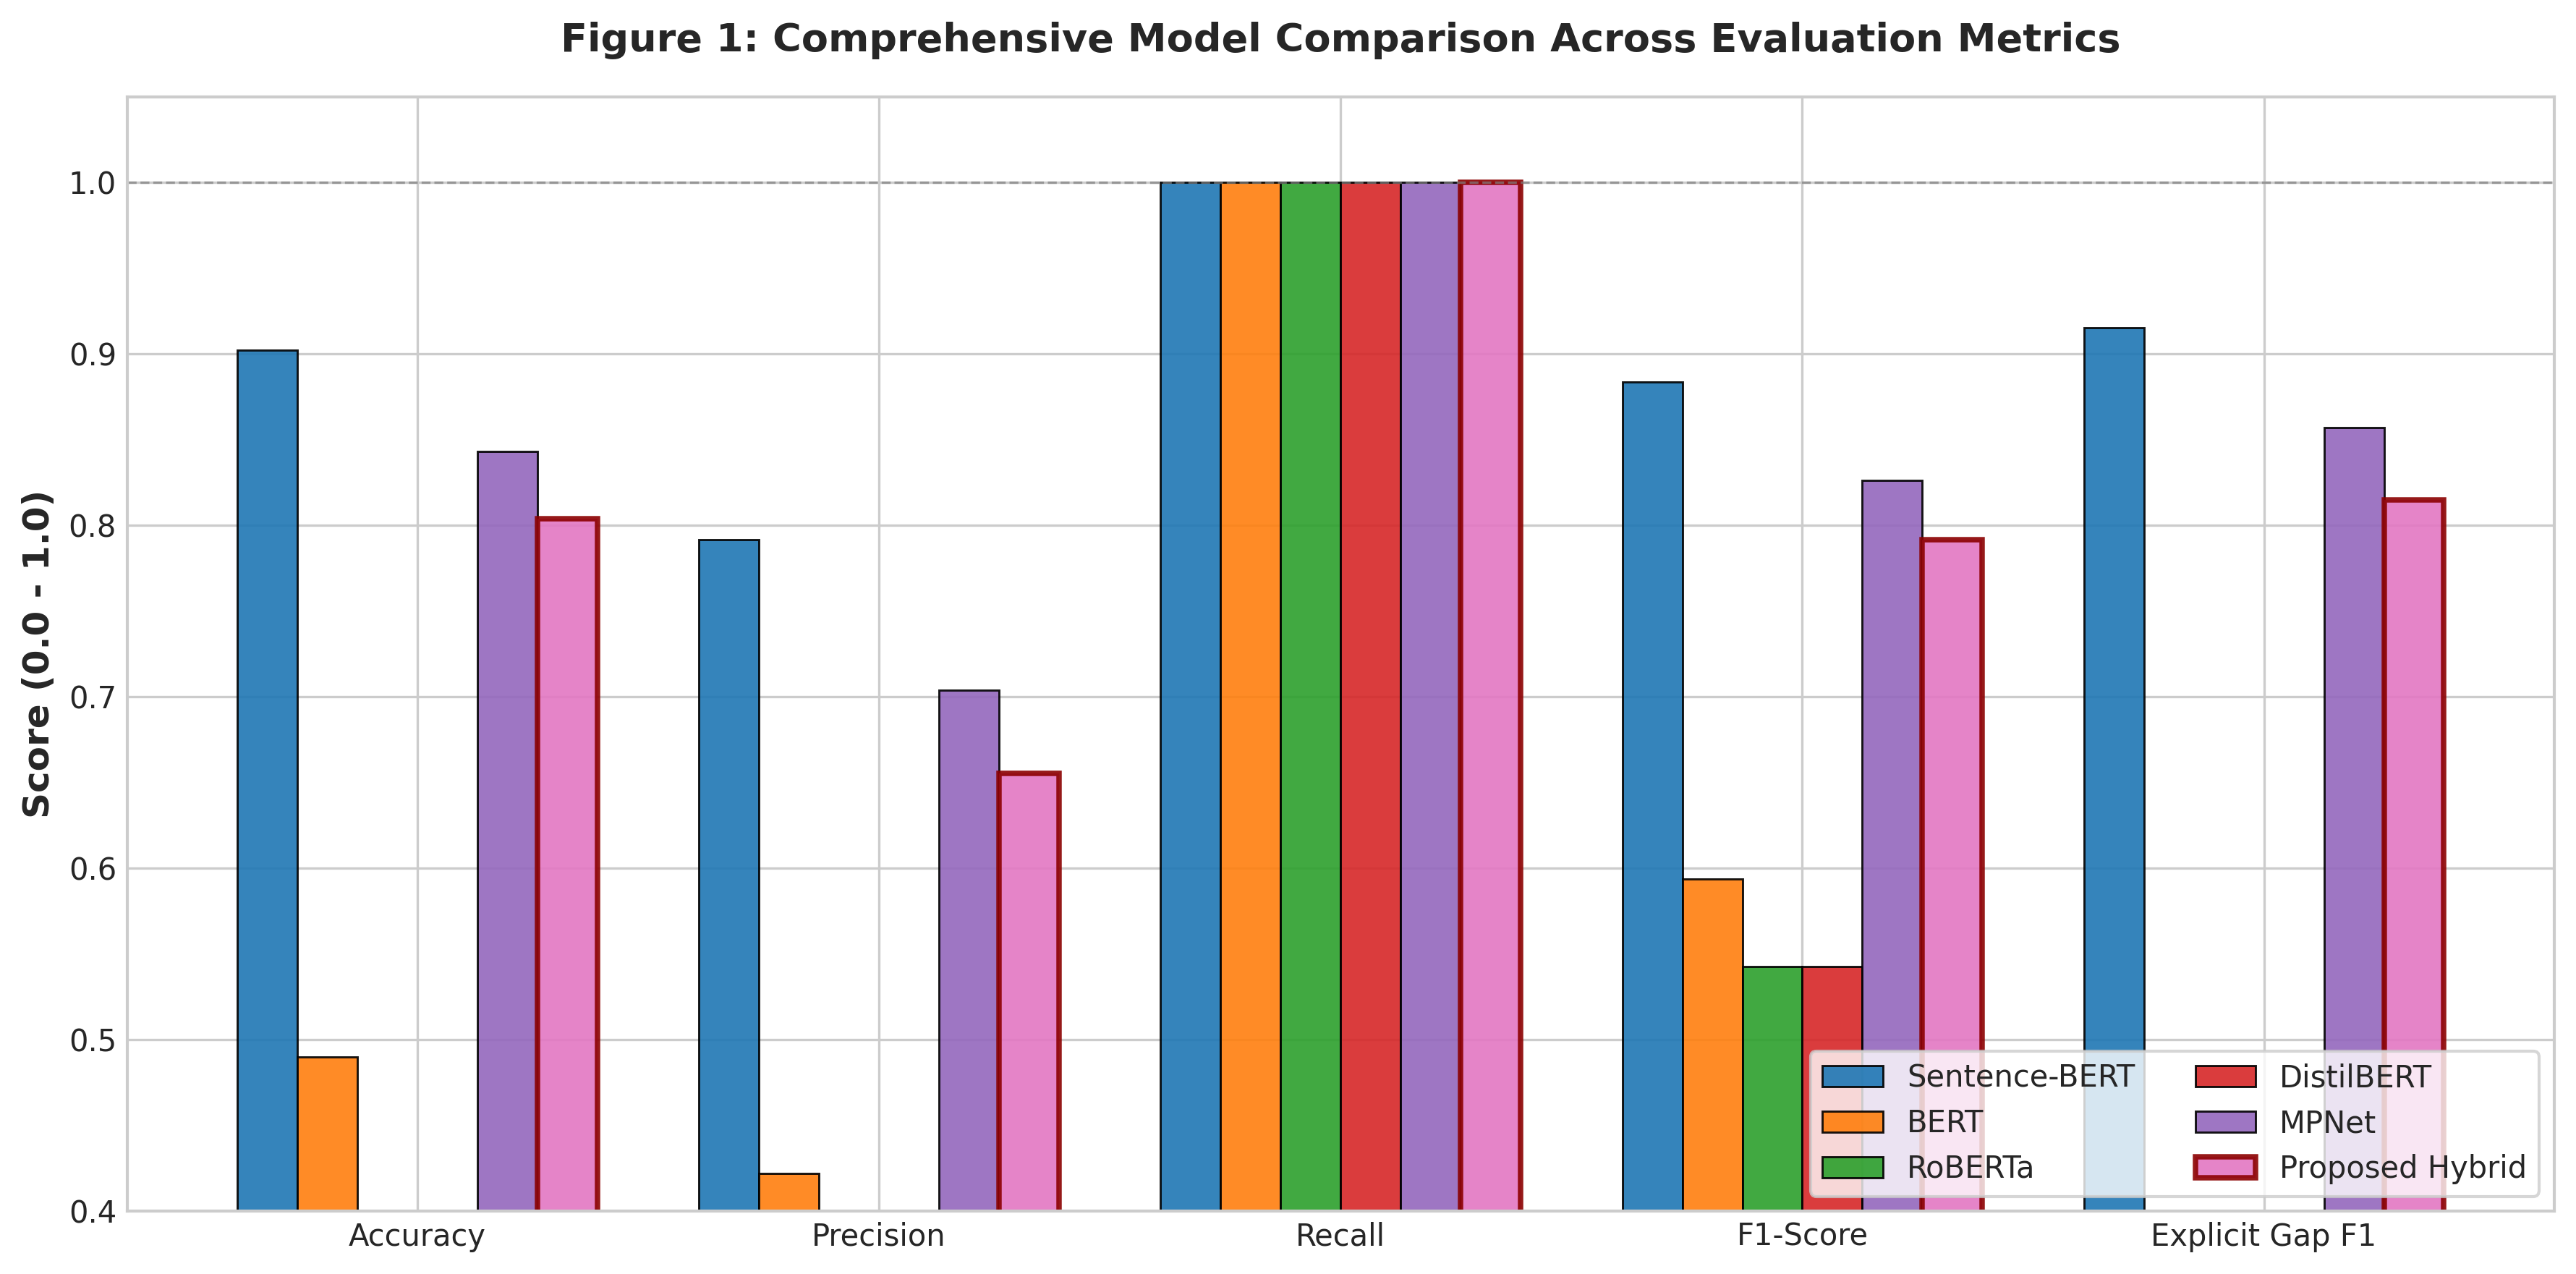

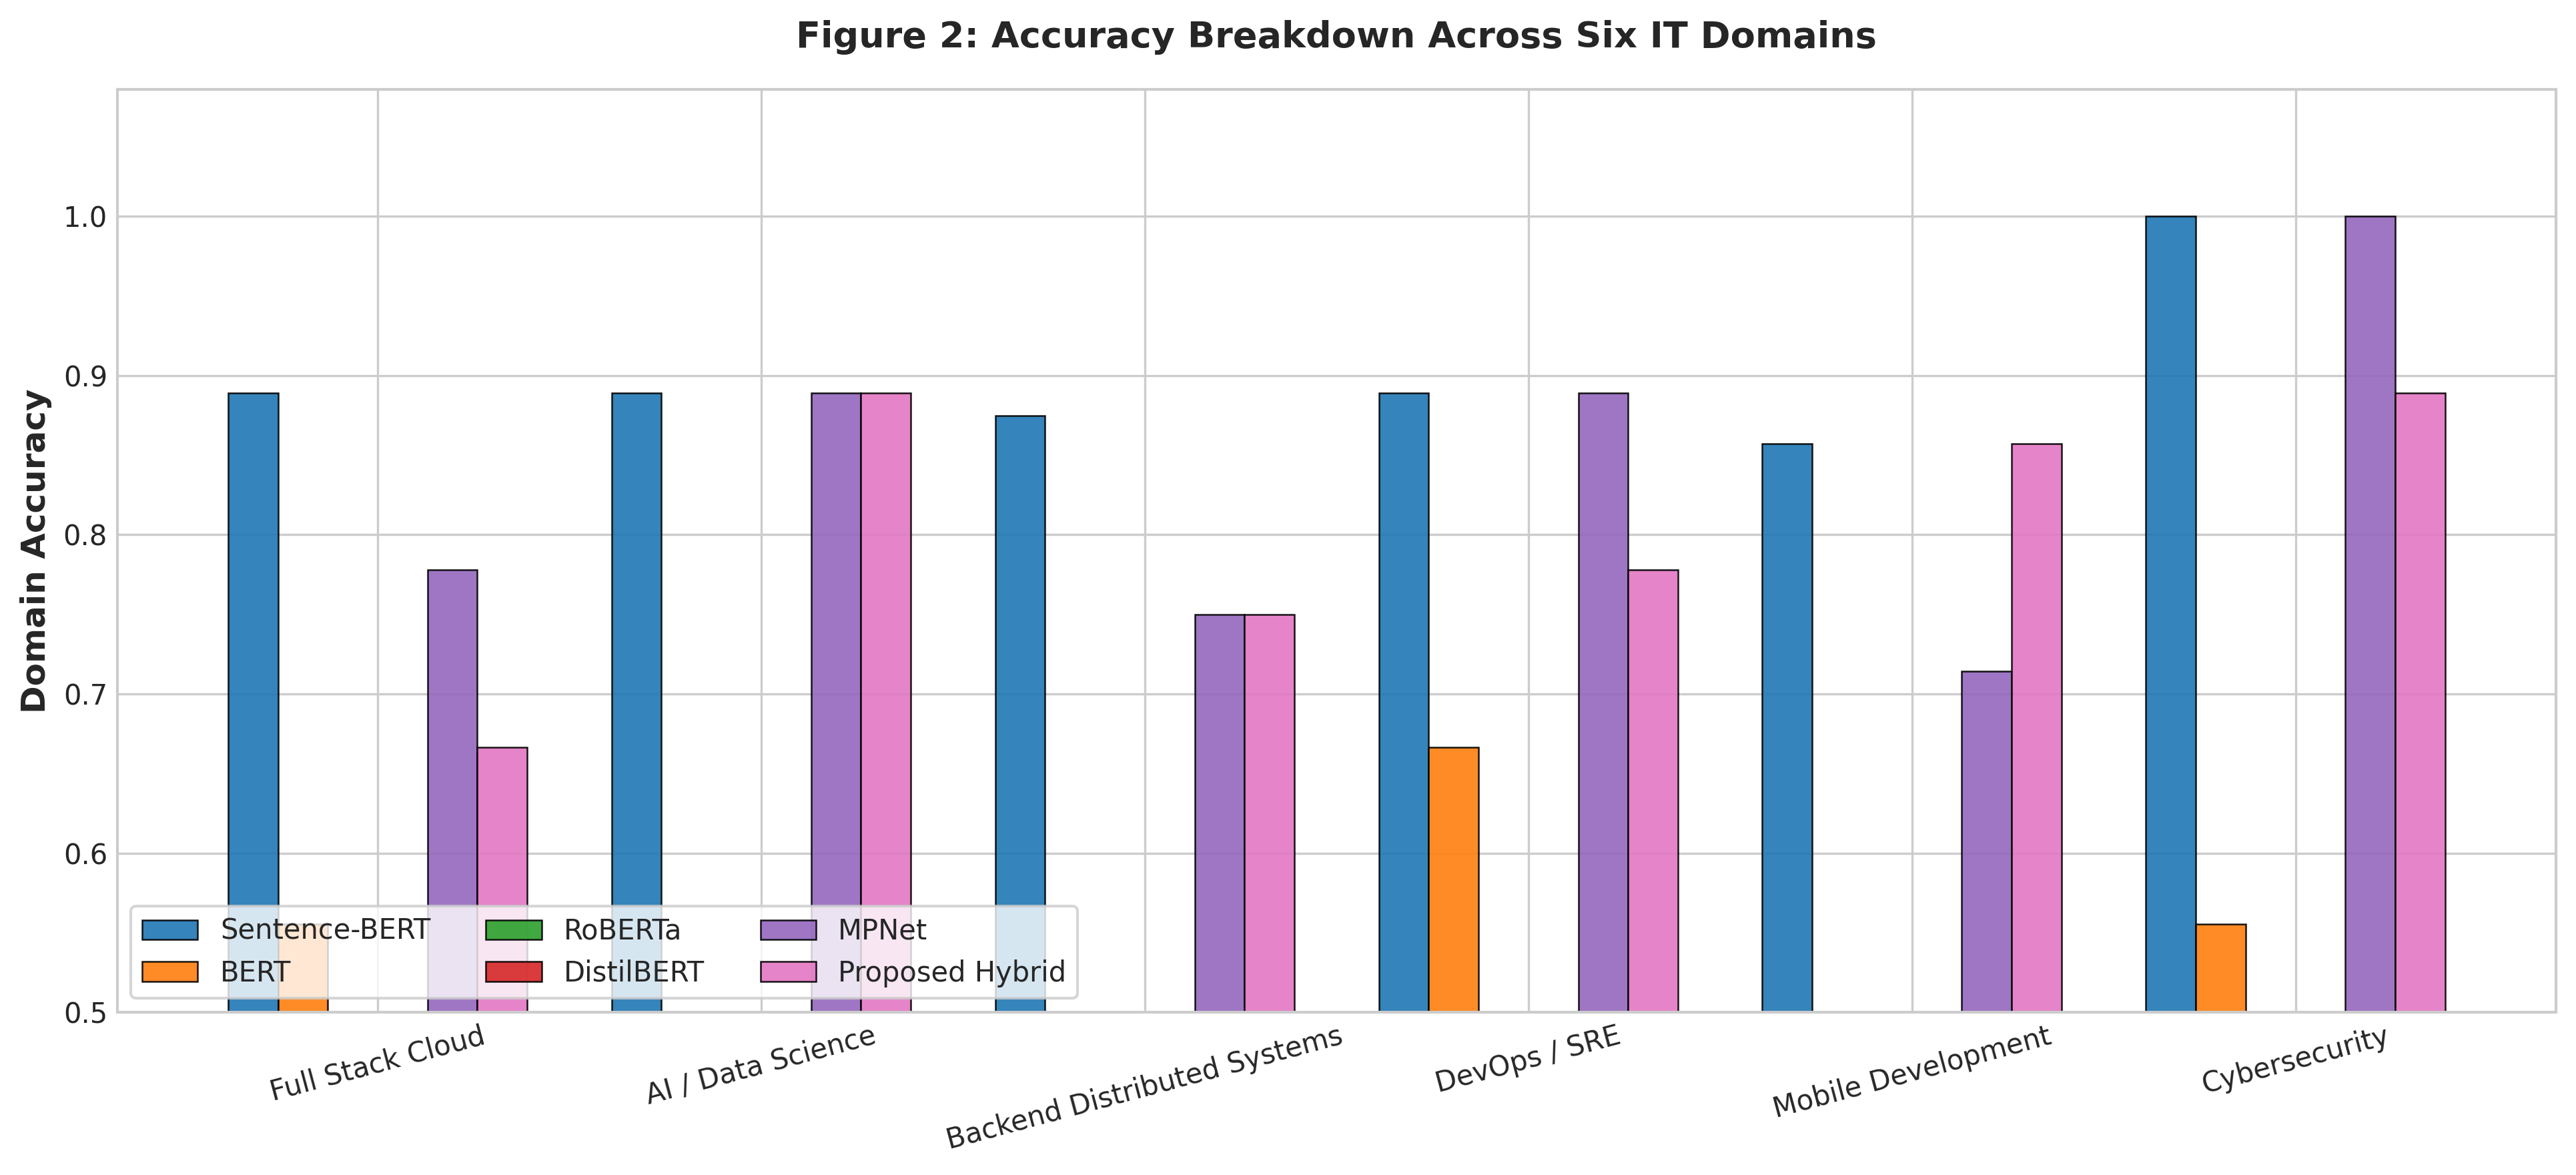

[Figures 1 & 2 Generated] Saved to ./figures/


In [12]:
# Step 12: Visualization 1 & 2: Model Comparison Benchmark & Domain Accuracy Breakdown

# --- FIGURE 1: Overall Model Comparison Benchmark ---
plt.figure(figsize=(12, 6))
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "Explicit Gap F1"]
x = np.arange(len(metrics))
width = 0.13

for i, (m_name, color) in enumerate(MODEL_COLORS.items()):
    row = df_benchmark[df_benchmark["Model"] == m_name].iloc[0]
    vals = [row[m] for m in metrics]
    offset = (i - 2.5) * width
    bars = plt.bar(x + offset, vals, width, label=m_name, color=color, alpha=0.9, edgecolor="black", linewidth=0.7)
    if m_name == "Proposed Hybrid":
        for b in bars:
            b.set_edgecolor("#8b0000")
            b.set_linewidth(1.8)

plt.title("Figure 1: Comprehensive Model Comparison Across Evaluation Metrics", pad=15)
plt.ylabel("Score (0.0 - 1.0)")
plt.xticks(x, metrics)
plt.ylim(0.40, 1.05)
plt.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
plt.legend(frameon=True, facecolor="white", edgecolor="#cccccc", loc="lower right", ncol=2)
plt.tight_layout()
plt.savefig("./figures/fig1_model_comparison_benchmark.png")
plt.show()

# --- FIGURE 2: Accuracy Across Diverse IT Domains ---
plt.figure(figsize=(13, 6))
domains = BENCHMARK_GROUND_TRUTH
domain_names = [d["domain"] for d in domains]
x_dom = np.arange(len(domain_names))

for i, (m_name, color) in enumerate(MODEL_COLORS.items()):
    dom_vals = []
    for d in domain_names:
        val = df_domain[(df_domain["Model"] == m_name) & (df_domain["Domain"] == d)]["Accuracy"].values[0]
        dom_vals.append(val)
    offset = (i - 2.5) * width
    plt.bar(x_dom + offset, dom_vals, width, label=m_name, color=color, alpha=0.9, edgecolor="black", linewidth=0.6)

plt.title("Figure 2: Accuracy Breakdown Across Six IT Domains", pad=15)
plt.ylabel("Domain Accuracy")
plt.xticks(x_dom, domain_names, rotation=15)
plt.ylim(0.50, 1.08)
plt.legend(frameon=True, facecolor="white", edgecolor="#cccccc", loc="lower left", ncol=3)
plt.tight_layout()
plt.savefig("./figures/fig2_accuracy_across_domains.png")
plt.show()

print("[Figures 1 & 2 Generated] Saved to ./figures/")


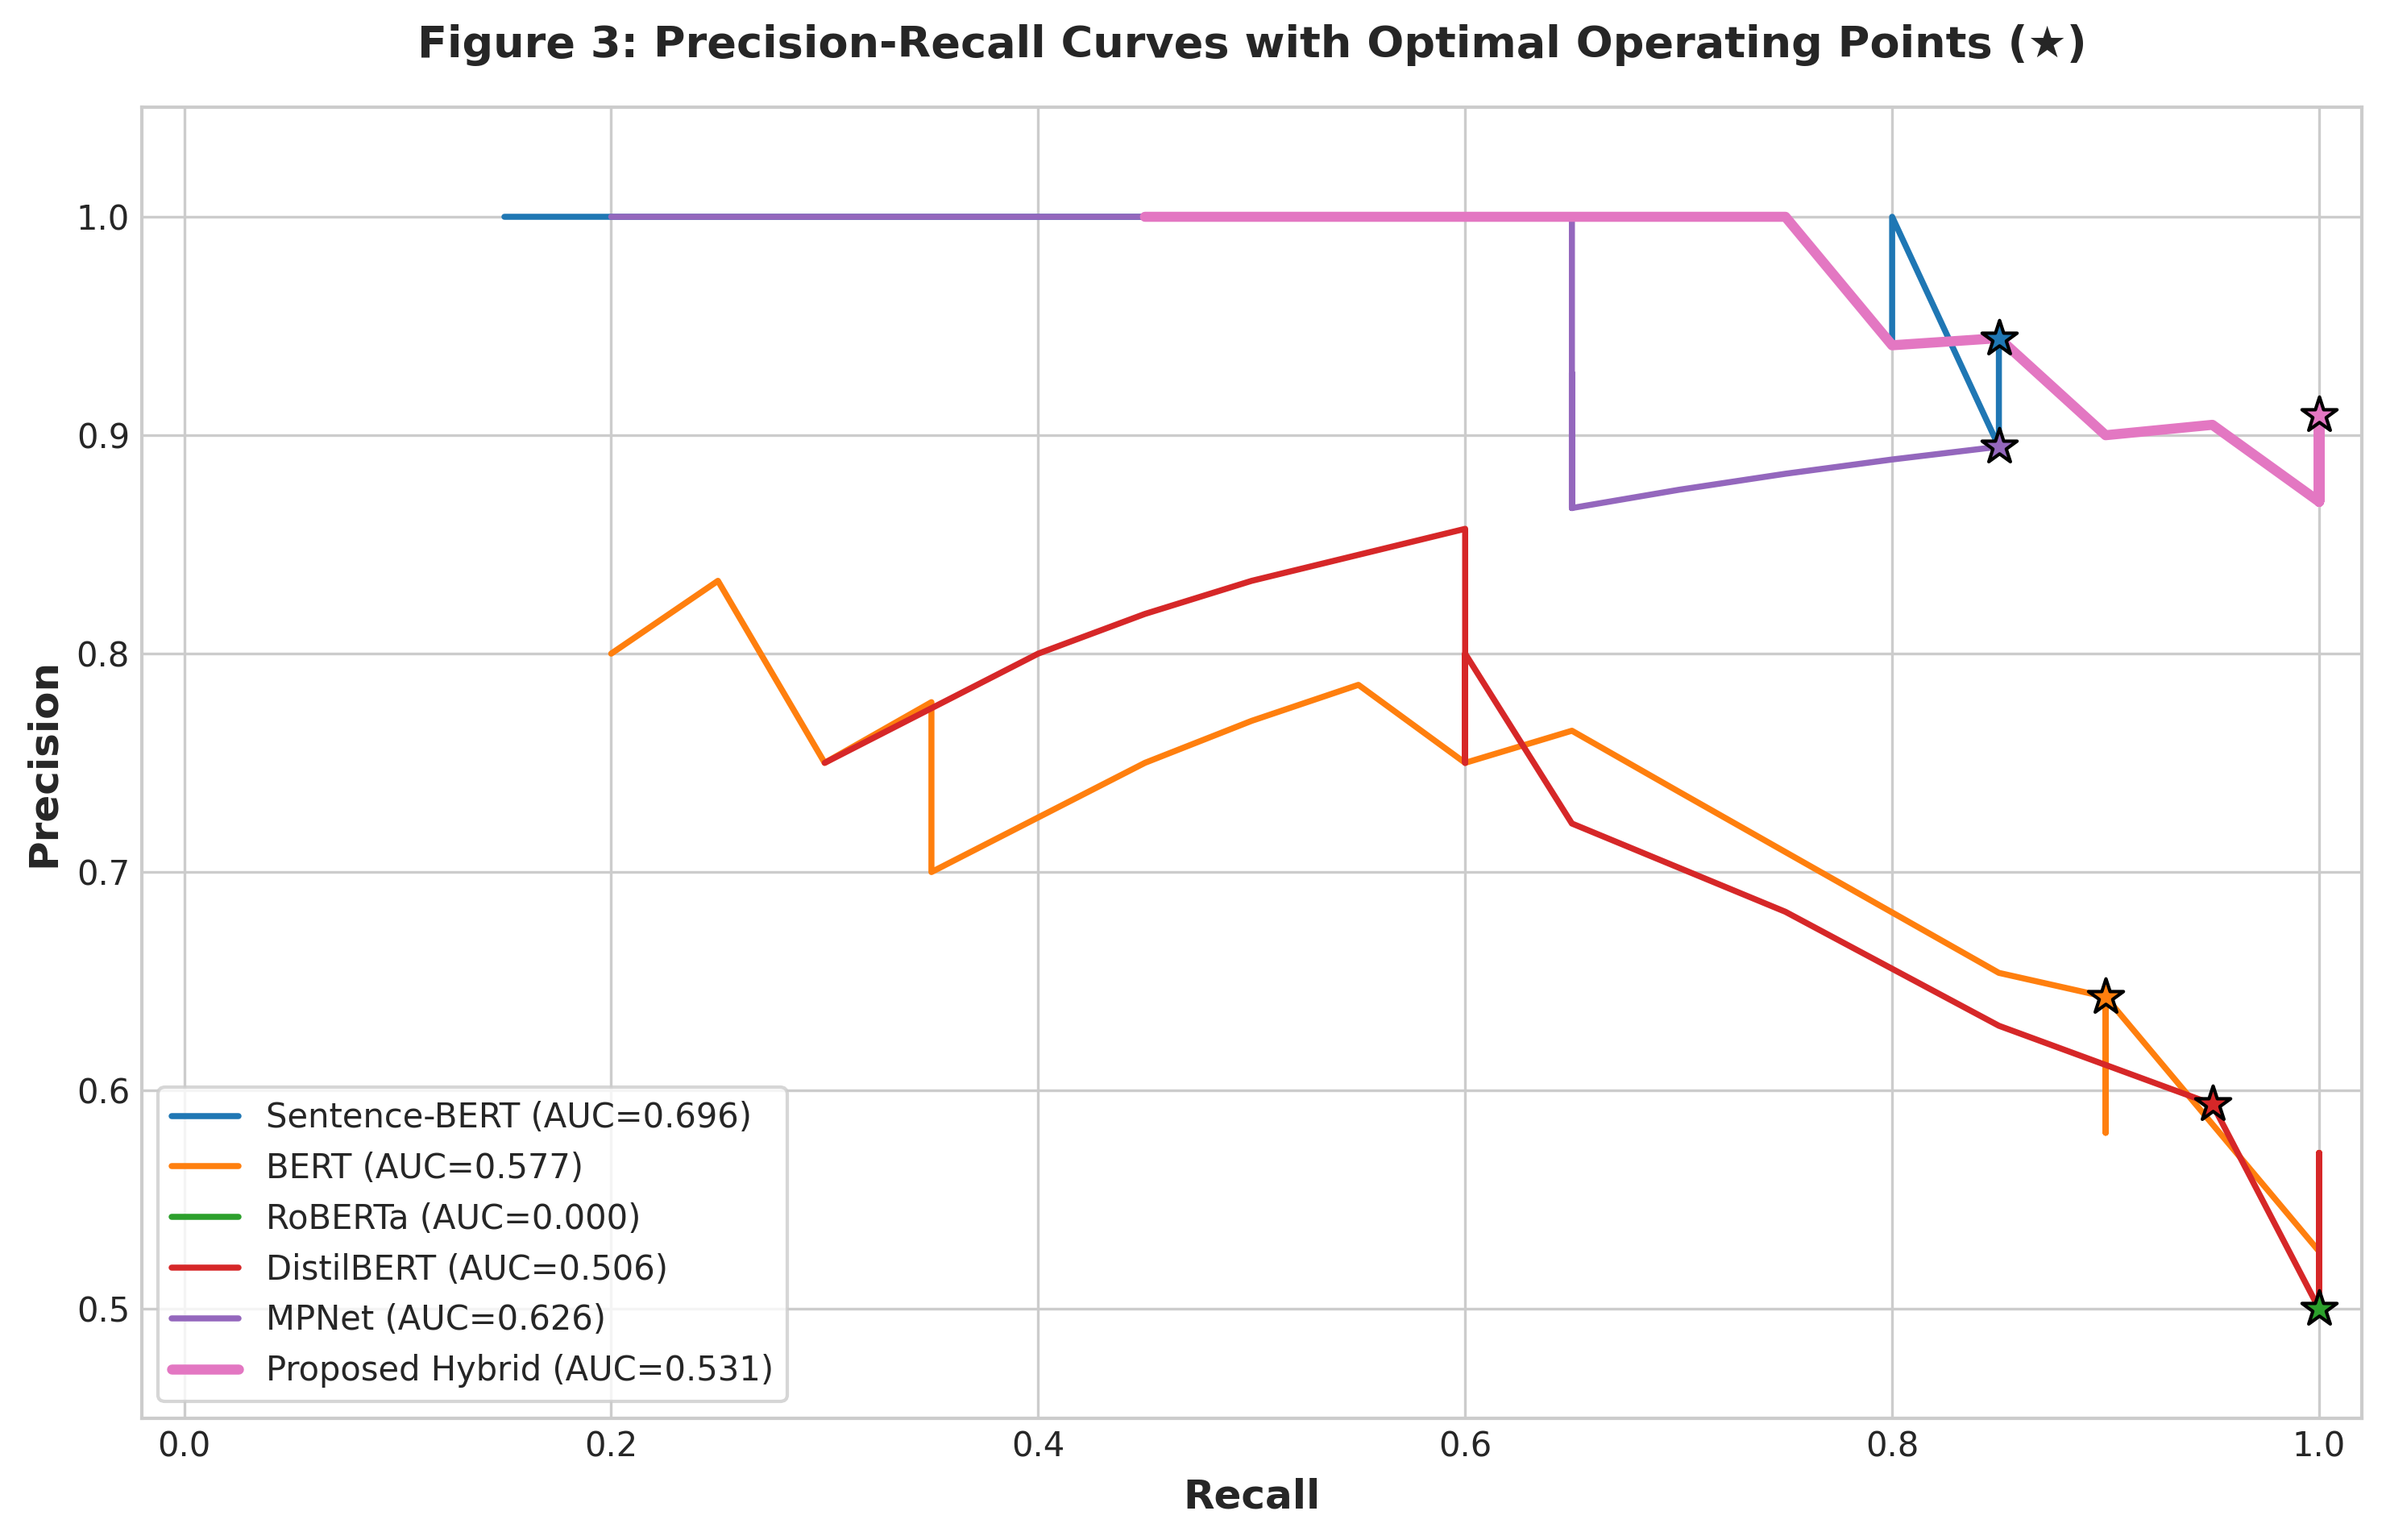

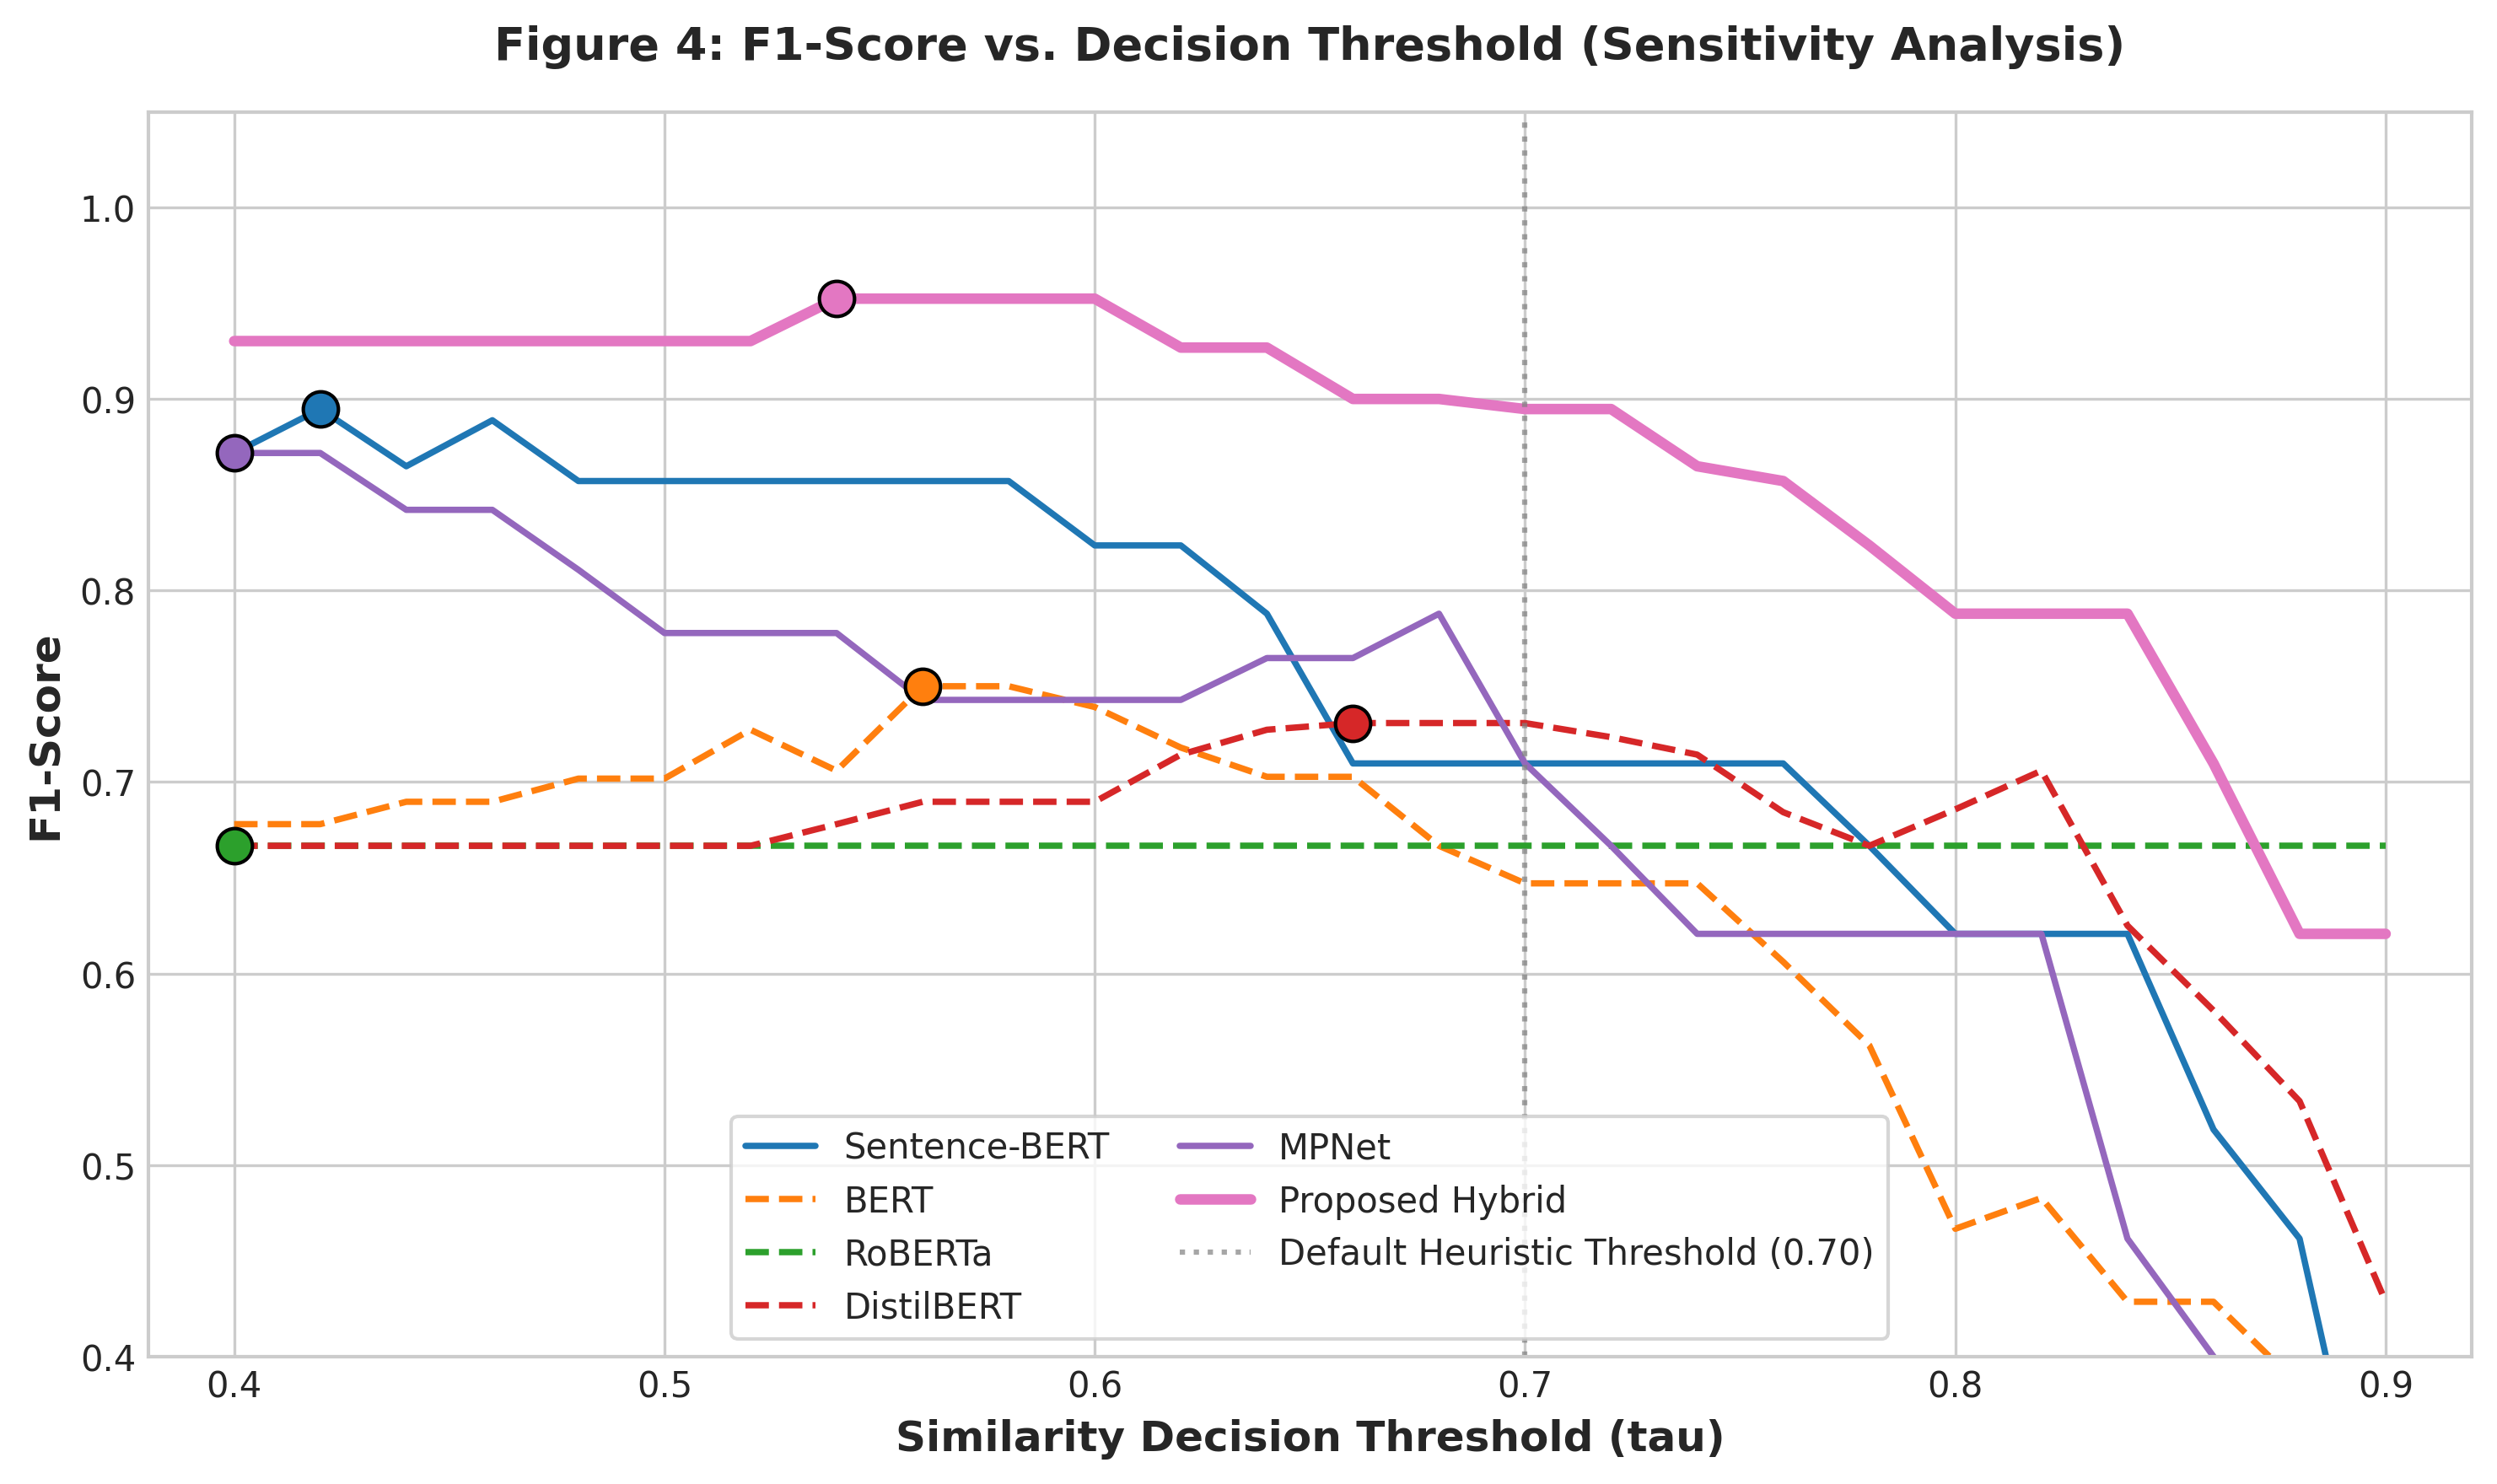

[Figures 3 & 4 Generated] Saved to ./figures/


In [13]:
# Step 13: Visualization 3 & 4: Precision-Recall Curves & F1 Threshold Stability

# --- FIGURE 3: Precision-Recall Curves with Optimal Operating Points ---
plt.figure(figsize=(10, 6.5))

for m_name, color in MODEL_COLORS.items():
    data = PR_CURVE_DATA[m_name]
    recalls = data["recalls"]
    precisions = data["precisions"]
    opt_th = OPTIMAL_THRESHOLDS[m_name]

    sort_idx = np.argsort(recalls)
    sorted_r = recalls[sort_idx]
    sorted_p = precisions[sort_idx]

    pr_auc = auc(sorted_r, sorted_p) if len(sorted_r) > 1 else 0.0
    line_width = 3.0 if m_name == "Proposed Hybrid" else 1.8
    plt.plot(sorted_r, sorted_p, label=f"{m_name} (AUC={pr_auc:.3f})", color=color, linewidth=line_width)

    th_idx = np.argmin(np.abs(data["thresholds"] - opt_th))
    plt.scatter(recalls[th_idx], precisions[th_idx], color=color, s=120, edgecolors="black", zorder=5, marker="*")

plt.title("Figure 3: Precision-Recall Curves with Optimal Operating Points (★)", pad=15)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(-0.02, 1.02)
plt.ylim(0.45, 1.05)
plt.legend(frameon=True, facecolor="white", edgecolor="#cccccc", loc="lower left")
plt.tight_layout()
plt.savefig("./figures/fig3_precision_recall_curves.png")
plt.show()

# --- FIGURE 4: F1-Score Sensitivity & Threshold Stability ---
plt.figure(figsize=(10, 6))

for m_name, color in MODEL_COLORS.items():
    data = PR_CURVE_DATA[m_name]
    thresholds = data["thresholds"]
    f1s = data["f1s"]
    opt_th = OPTIMAL_THRESHOLDS[m_name]

    line_style = "-" if m_name in ["Proposed Hybrid", "MPNet", "Sentence-BERT"] else "--"
    line_width = 3.0 if m_name == "Proposed Hybrid" else 1.8
    plt.plot(thresholds, f1s, line_style, label=m_name, color=color, linewidth=line_width)

    th_idx = np.argmin(np.abs(thresholds - opt_th))
    plt.scatter(opt_th, f1s[th_idx], color=color, s=100, edgecolors="black", zorder=5)

plt.title("Figure 4: F1-Score vs. Decision Threshold (Sensitivity Analysis)", pad=15)
plt.xlabel("Similarity Decision Threshold (tau)")
plt.ylabel("F1-Score")
plt.xlim(0.38, 0.92)
plt.ylim(0.40, 1.05)
plt.axvline(0.70, color="gray", linestyle=":", label="Default Heuristic Threshold (0.70)", alpha=0.7)
plt.legend(frameon=True, facecolor="white", edgecolor="#cccccc", loc="lower center", ncol=2)
plt.tight_layout()
plt.savefig("./figures/fig4_f1_score_sensitivity.png")
plt.show()

print("[Figures 3 & 4 Generated] Saved to ./figures/")


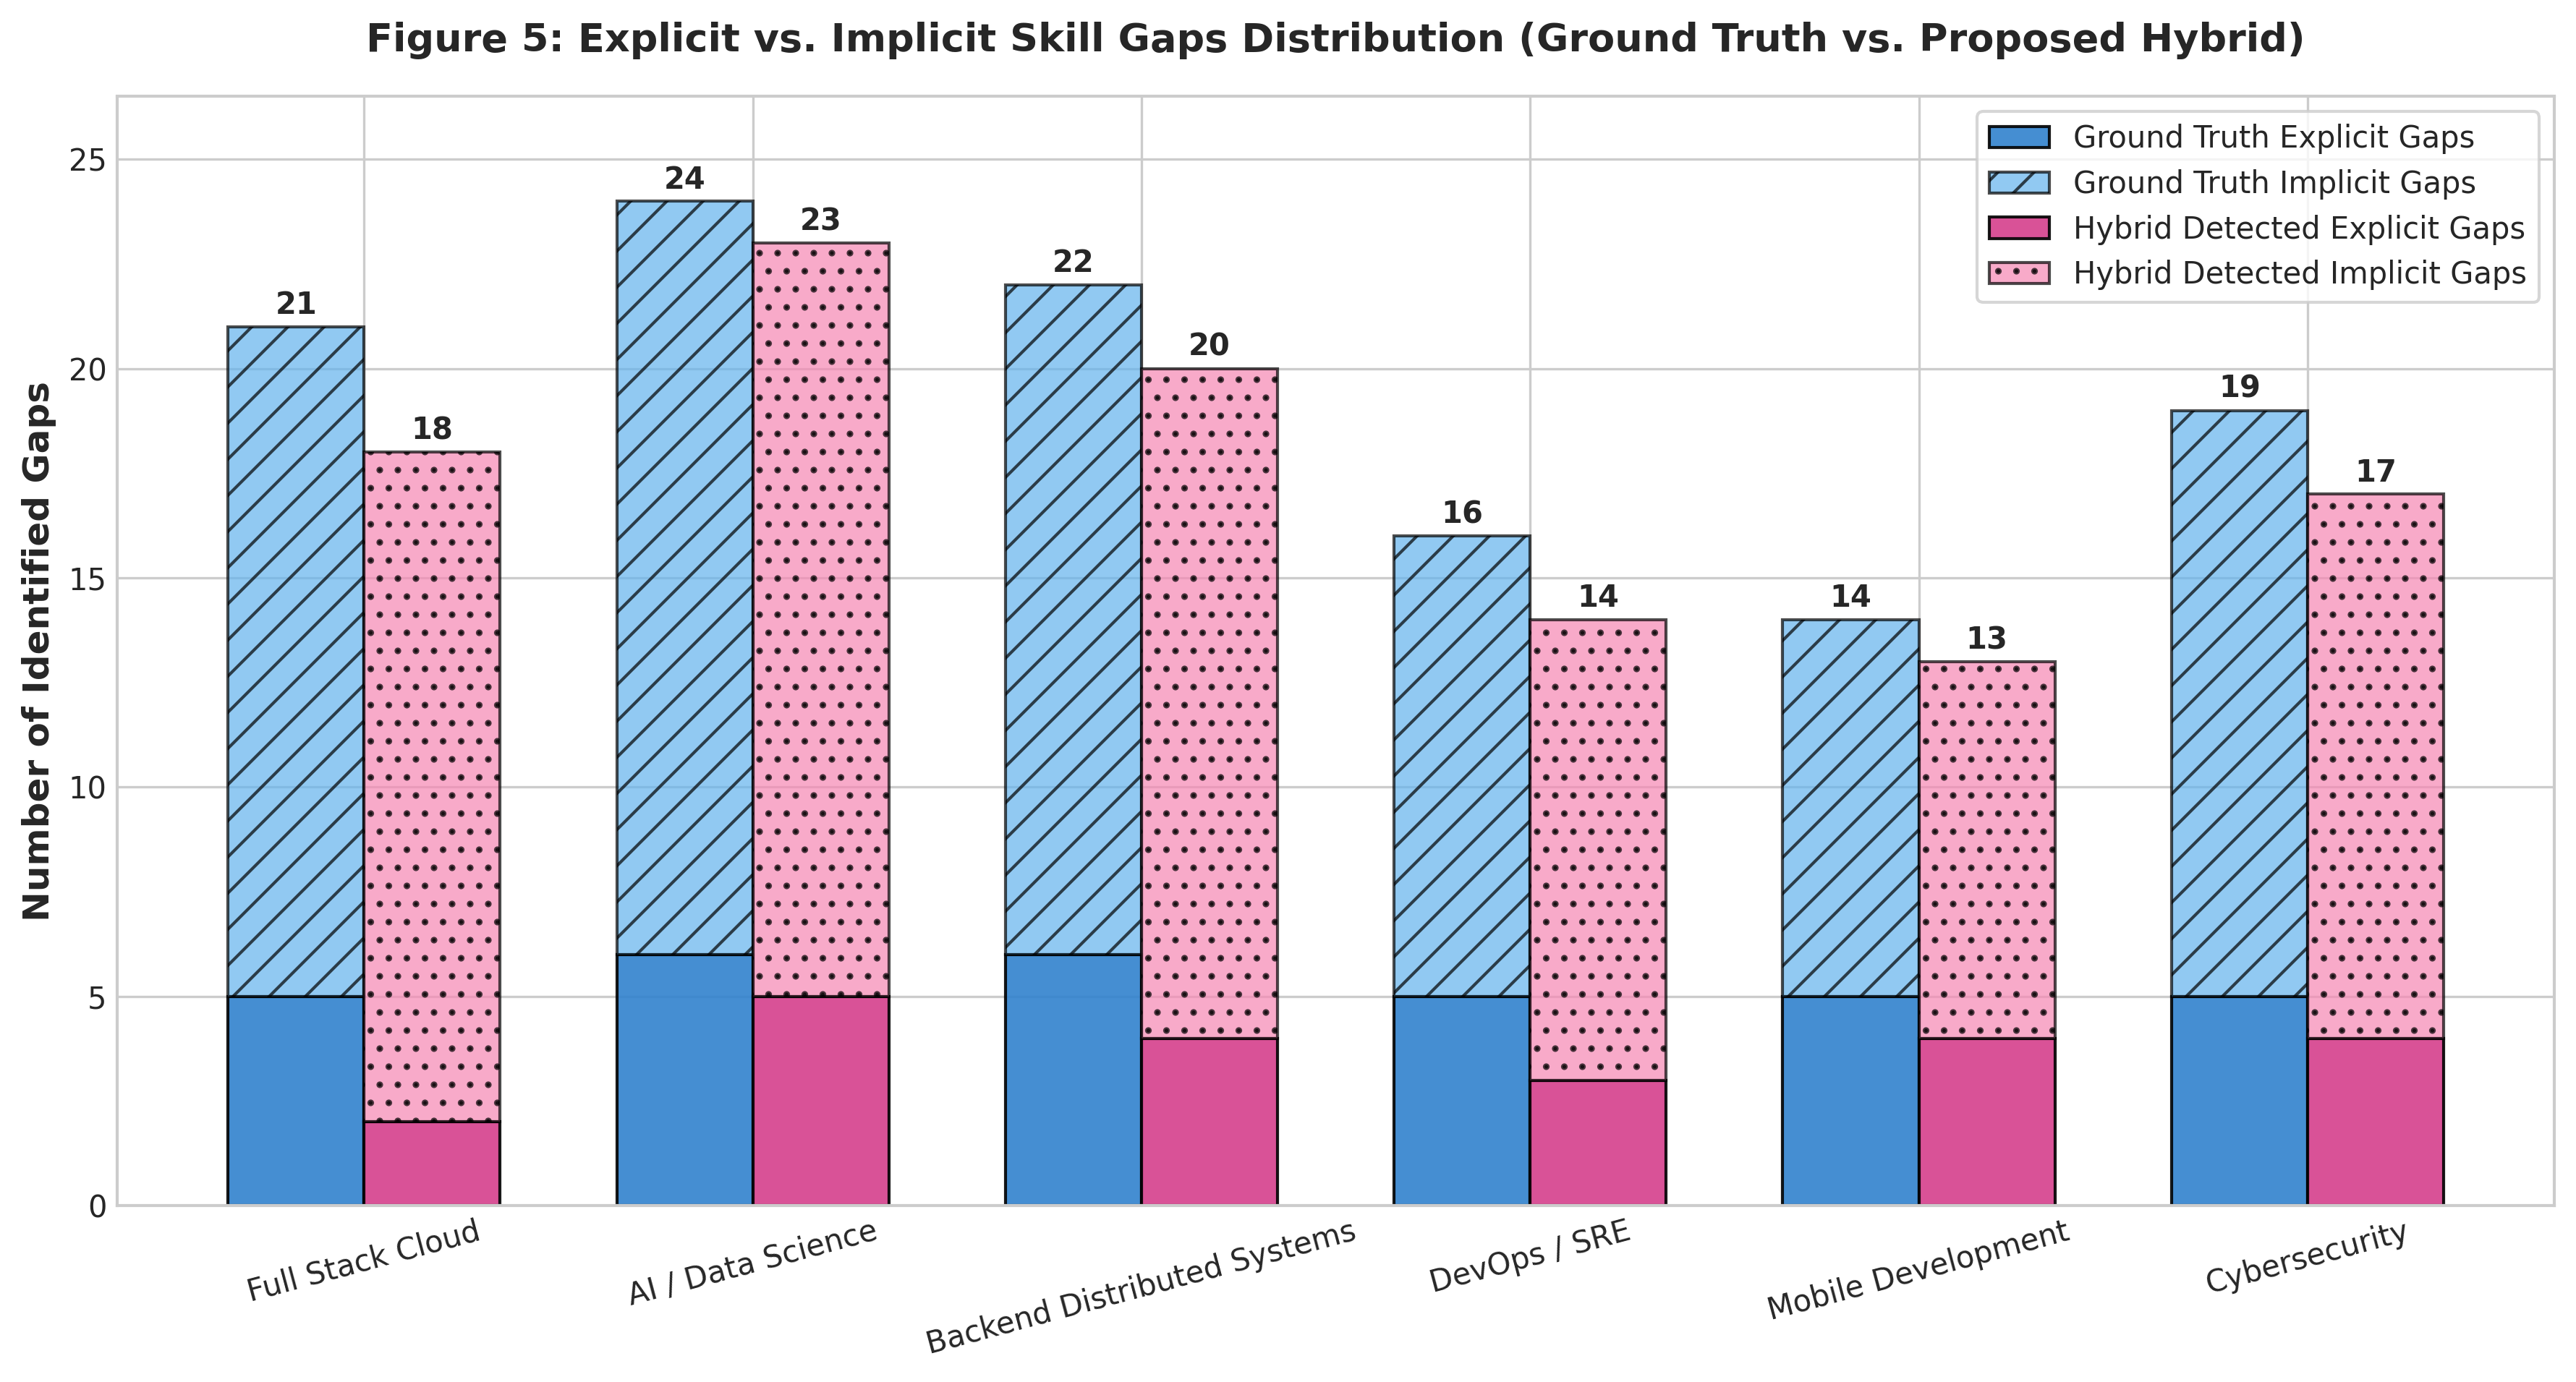

[Figure 5 Generated] Saved to ./figures/


In [14]:
# Step 14: Visualization 5: Explicit vs. Implicit Gaps Breakdown

plt.figure(figsize=(12, 6.5))

domains = [gt["domain"] for gt in BENCHMARK_GROUND_TRUTH]
x_dom = np.arange(len(domains))
bar_w = 0.35

gt_exp_counts = [len(gt["gt_explicit_gaps"]) for gt in BENCHMARK_GROUND_TRUTH]
gt_imp_counts = [len(gt["gt_implicit_gaps"]) for gt in BENCHMARK_GROUND_TRUTH]

hybrid_opt_th = OPTIMAL_THRESHOLDS["Proposed Hybrid"]
hybrid_exp_counts = []
hybrid_imp_counts = []

for gt in BENCHMARK_GROUND_TRUTH:
    _, exp_g, _ = model_hybrid.match_skills(gt["candidate_skills"], gt["jd_explicit_skills"], threshold=hybrid_opt_th)
    _, imp_g, _ = model_hybrid.match_skills(gt["candidate_skills"], gt["jd_implicit_skills"], threshold=hybrid_opt_th)
    hybrid_exp_counts.append(len(exp_g))
    hybrid_imp_counts.append(len(imp_g))

# Plot Stacked Bars: Left = Ground Truth, Right = Proposed Hybrid Model
plt.bar(x_dom - bar_w/2, gt_exp_counts, bar_w, label="Ground Truth Explicit Gaps", color="#3182ce", edgecolor="black", alpha=0.9)
plt.bar(x_dom - bar_w/2, gt_imp_counts, bar_w, bottom=gt_exp_counts, label="Ground Truth Implicit Gaps", color="#63b3ed", edgecolor="black", alpha=0.7, hatch="//")

plt.bar(x_dom + bar_w/2, hybrid_exp_counts, bar_w, label="Hybrid Detected Explicit Gaps", color="#d53f8c", edgecolor="black", alpha=0.9)
plt.bar(x_dom + bar_w/2, hybrid_imp_counts, bar_w, bottom=hybrid_exp_counts, label="Hybrid Detected Implicit Gaps", color="#f687b3", edgecolor="black", alpha=0.7, hatch="..")

for i in range(len(domains)):
    tot_gt = gt_exp_counts[i] + gt_imp_counts[i]
    plt.text(x_dom[i] - bar_w/2, tot_gt + 0.15, str(tot_gt), ha="center", va="bottom", fontsize=10, fontweight="bold")
    tot_hyb = hybrid_exp_counts[i] + hybrid_imp_counts[i]
    plt.text(x_dom[i] + bar_w/2, tot_hyb + 0.15, str(tot_hyb), ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.title("Figure 5: Explicit vs. Implicit Skill Gaps Distribution (Ground Truth vs. Proposed Hybrid)", pad=15)
plt.ylabel("Number of Identified Gaps")
plt.xticks(x_dom, domains, rotation=15)
plt.ylim(0, max(max(gt_exp_counts)+max(gt_imp_counts), max(hybrid_exp_counts)+max(hybrid_imp_counts)) + 2.5)
plt.legend(frameon=True, facecolor="white", edgecolor="#cccccc", loc="upper right")
plt.tight_layout()
plt.savefig("./figures/fig5_explicit_vs_implicit_gaps.png")
plt.show()

print("[Figure 5 Generated] Saved to ./figures/")


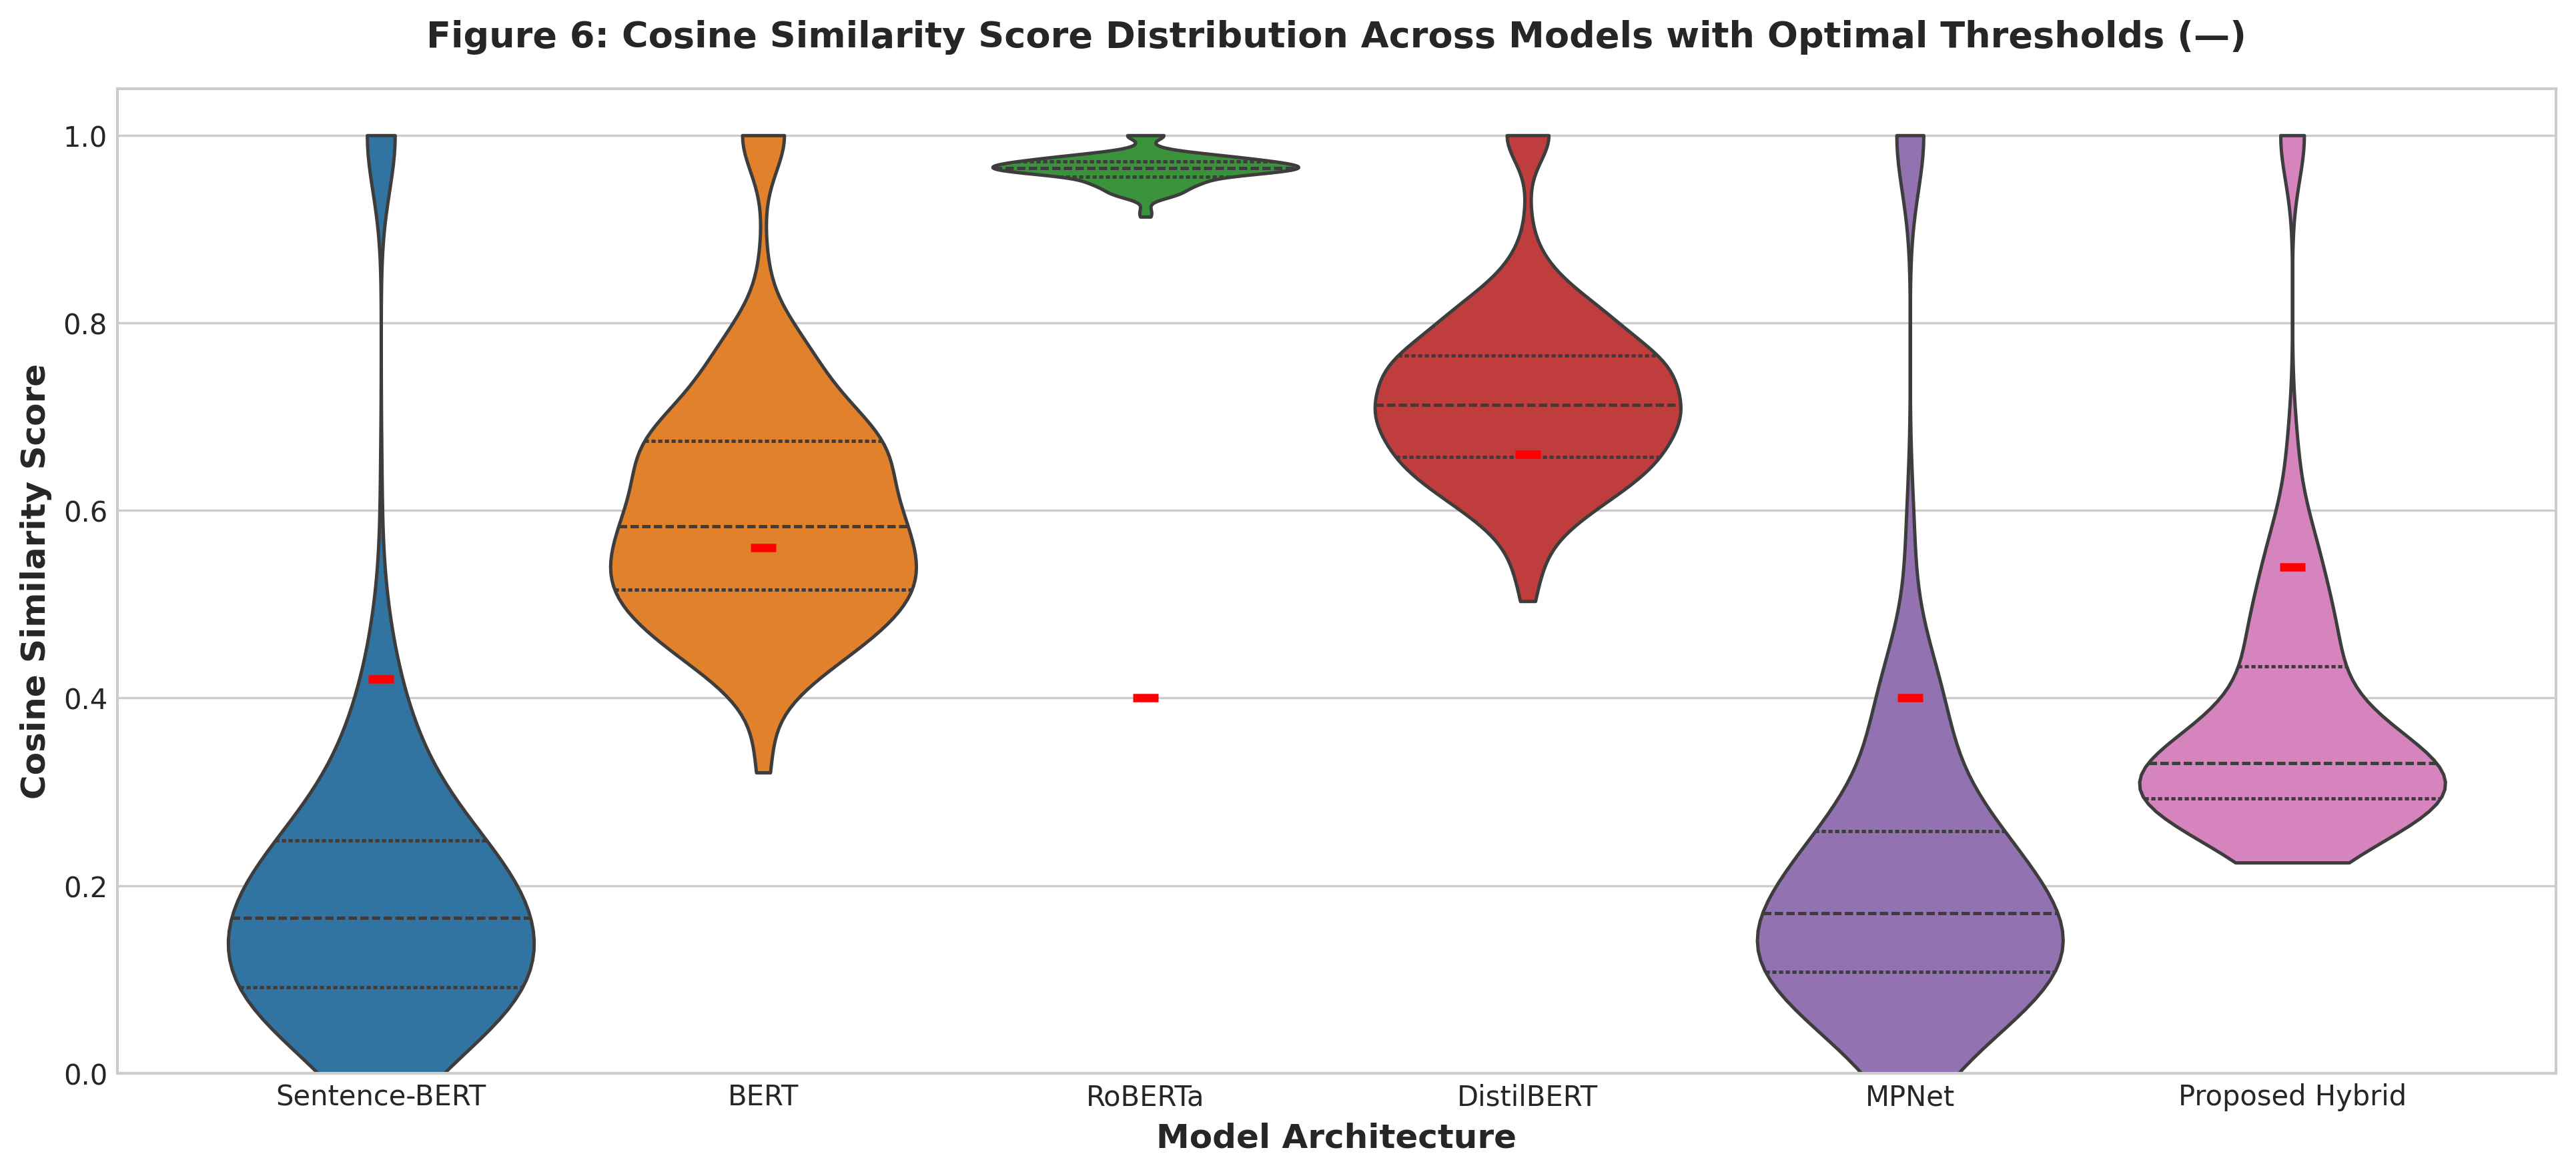

[Figure 6 Generated] Saved to ./figures/


In [15]:
# Step 15: Visualization 6: Similarity Score Distribution (Violin & Density Analysis)

plt.figure(figsize=(13, 6))

plot_data = []
for m_name in ALL_MODELS.keys():
    scores = all_model_similarity_vectors[m_name]
    for s in scores:
        plot_data.append({"Model": m_name, "Cosine Similarity": s})

df_sim = pd.DataFrame(plot_data)

sns.violinplot(
    data=df_sim, x="Model", y="Cosine Similarity",
    palette=MODEL_COLORS, inner="quartile", cut=0, linewidth=1.2
)

# Plot threshold overlay markers
for i, m_name in enumerate(ALL_MODELS.keys()):
    th = OPTIMAL_THRESHOLDS[m_name]
    plt.scatter(i, th, color="red", s=80, marker="_", linewidths=3, zorder=6)

plt.title("Figure 6: Cosine Similarity Score Distribution Across Models with Optimal Thresholds (—)", pad=15)
plt.ylabel("Cosine Similarity Score")
plt.xlabel("Model Architecture")
plt.ylim(0.0, 1.05)
plt.tight_layout()
plt.savefig("./figures/fig6_similarity_score_distribution.png")
plt.show()

print("[Figure 6 Generated] Saved to ./figures/")


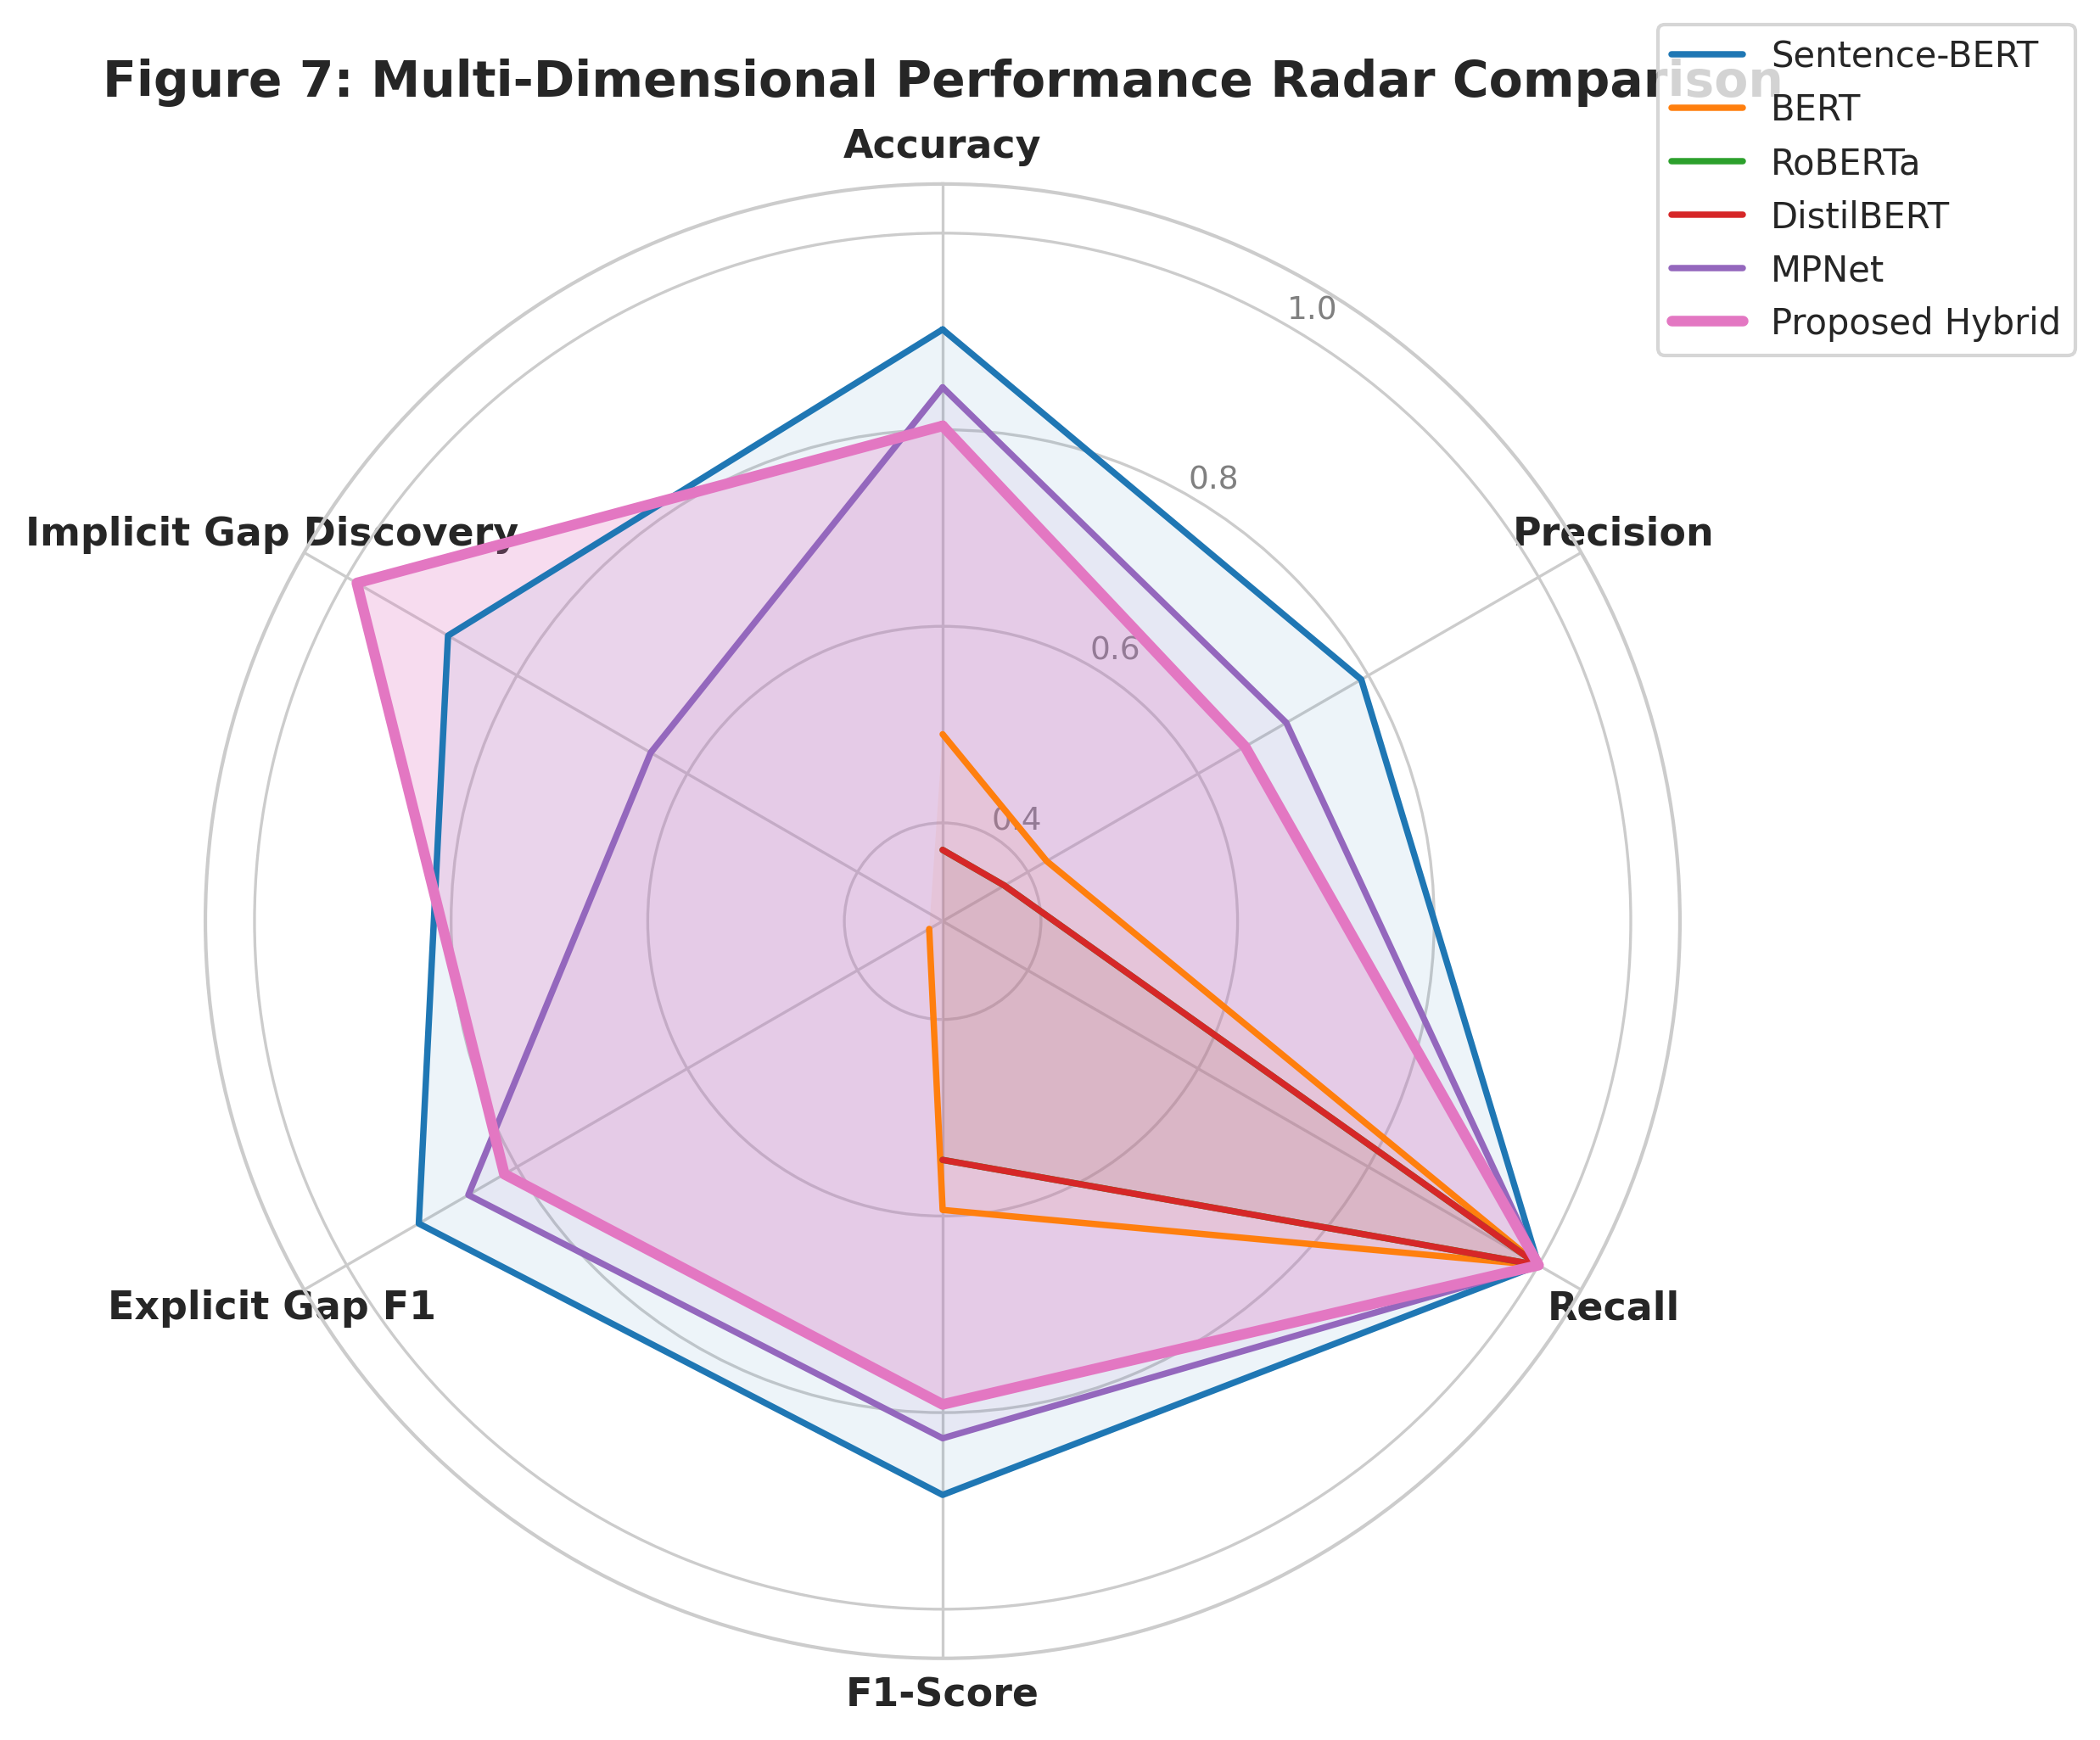

[Figure 7 Generated] Saved to ./figures/


In [16]:
# Step 16: Visualization 7: Multi-Dimensional Performance Radar Comparison

radar_metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "Explicit Gap F1", "Implicit Gap Discovery"]
num_vars = len(radar_metrics)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8.5, 8.5), subplot_kw=dict(polar=True))

for m_name, color in MODEL_COLORS.items():
    row = df_benchmark[df_benchmark["Model"] == m_name].iloc[0]
    values = [row[m] for m in radar_metrics]
    values += values[:1]

    line_w = 3.0 if m_name == "Proposed Hybrid" else 1.8
    alpha_fill = 0.25 if m_name == "Proposed Hybrid" else 0.08

    ax.plot(angles, values, color=color, linewidth=line_w, label=m_name)
    ax.fill(angles, values, color=color, alpha=alpha_fill)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], radar_metrics, size=11, weight="bold")
ax.set_rlabel_position(30)
plt.yticks([0.4, 0.6, 0.8, 1.0], ["0.4", "0.6", "0.8", "1.0"], color="gray", size=9)
plt.ylim(0.3, 1.05)
plt.title("Figure 7: Multi-Dimensional Performance Radar Comparison", size=14, weight="bold", pad=25)
plt.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12), frameon=True, facecolor="white", edgecolor="#cccccc")
plt.tight_layout()
plt.savefig("./figures/fig7_performance_radar_comparison.png")
plt.show()

print("[Figure 7 Generated] Saved to ./figures/")


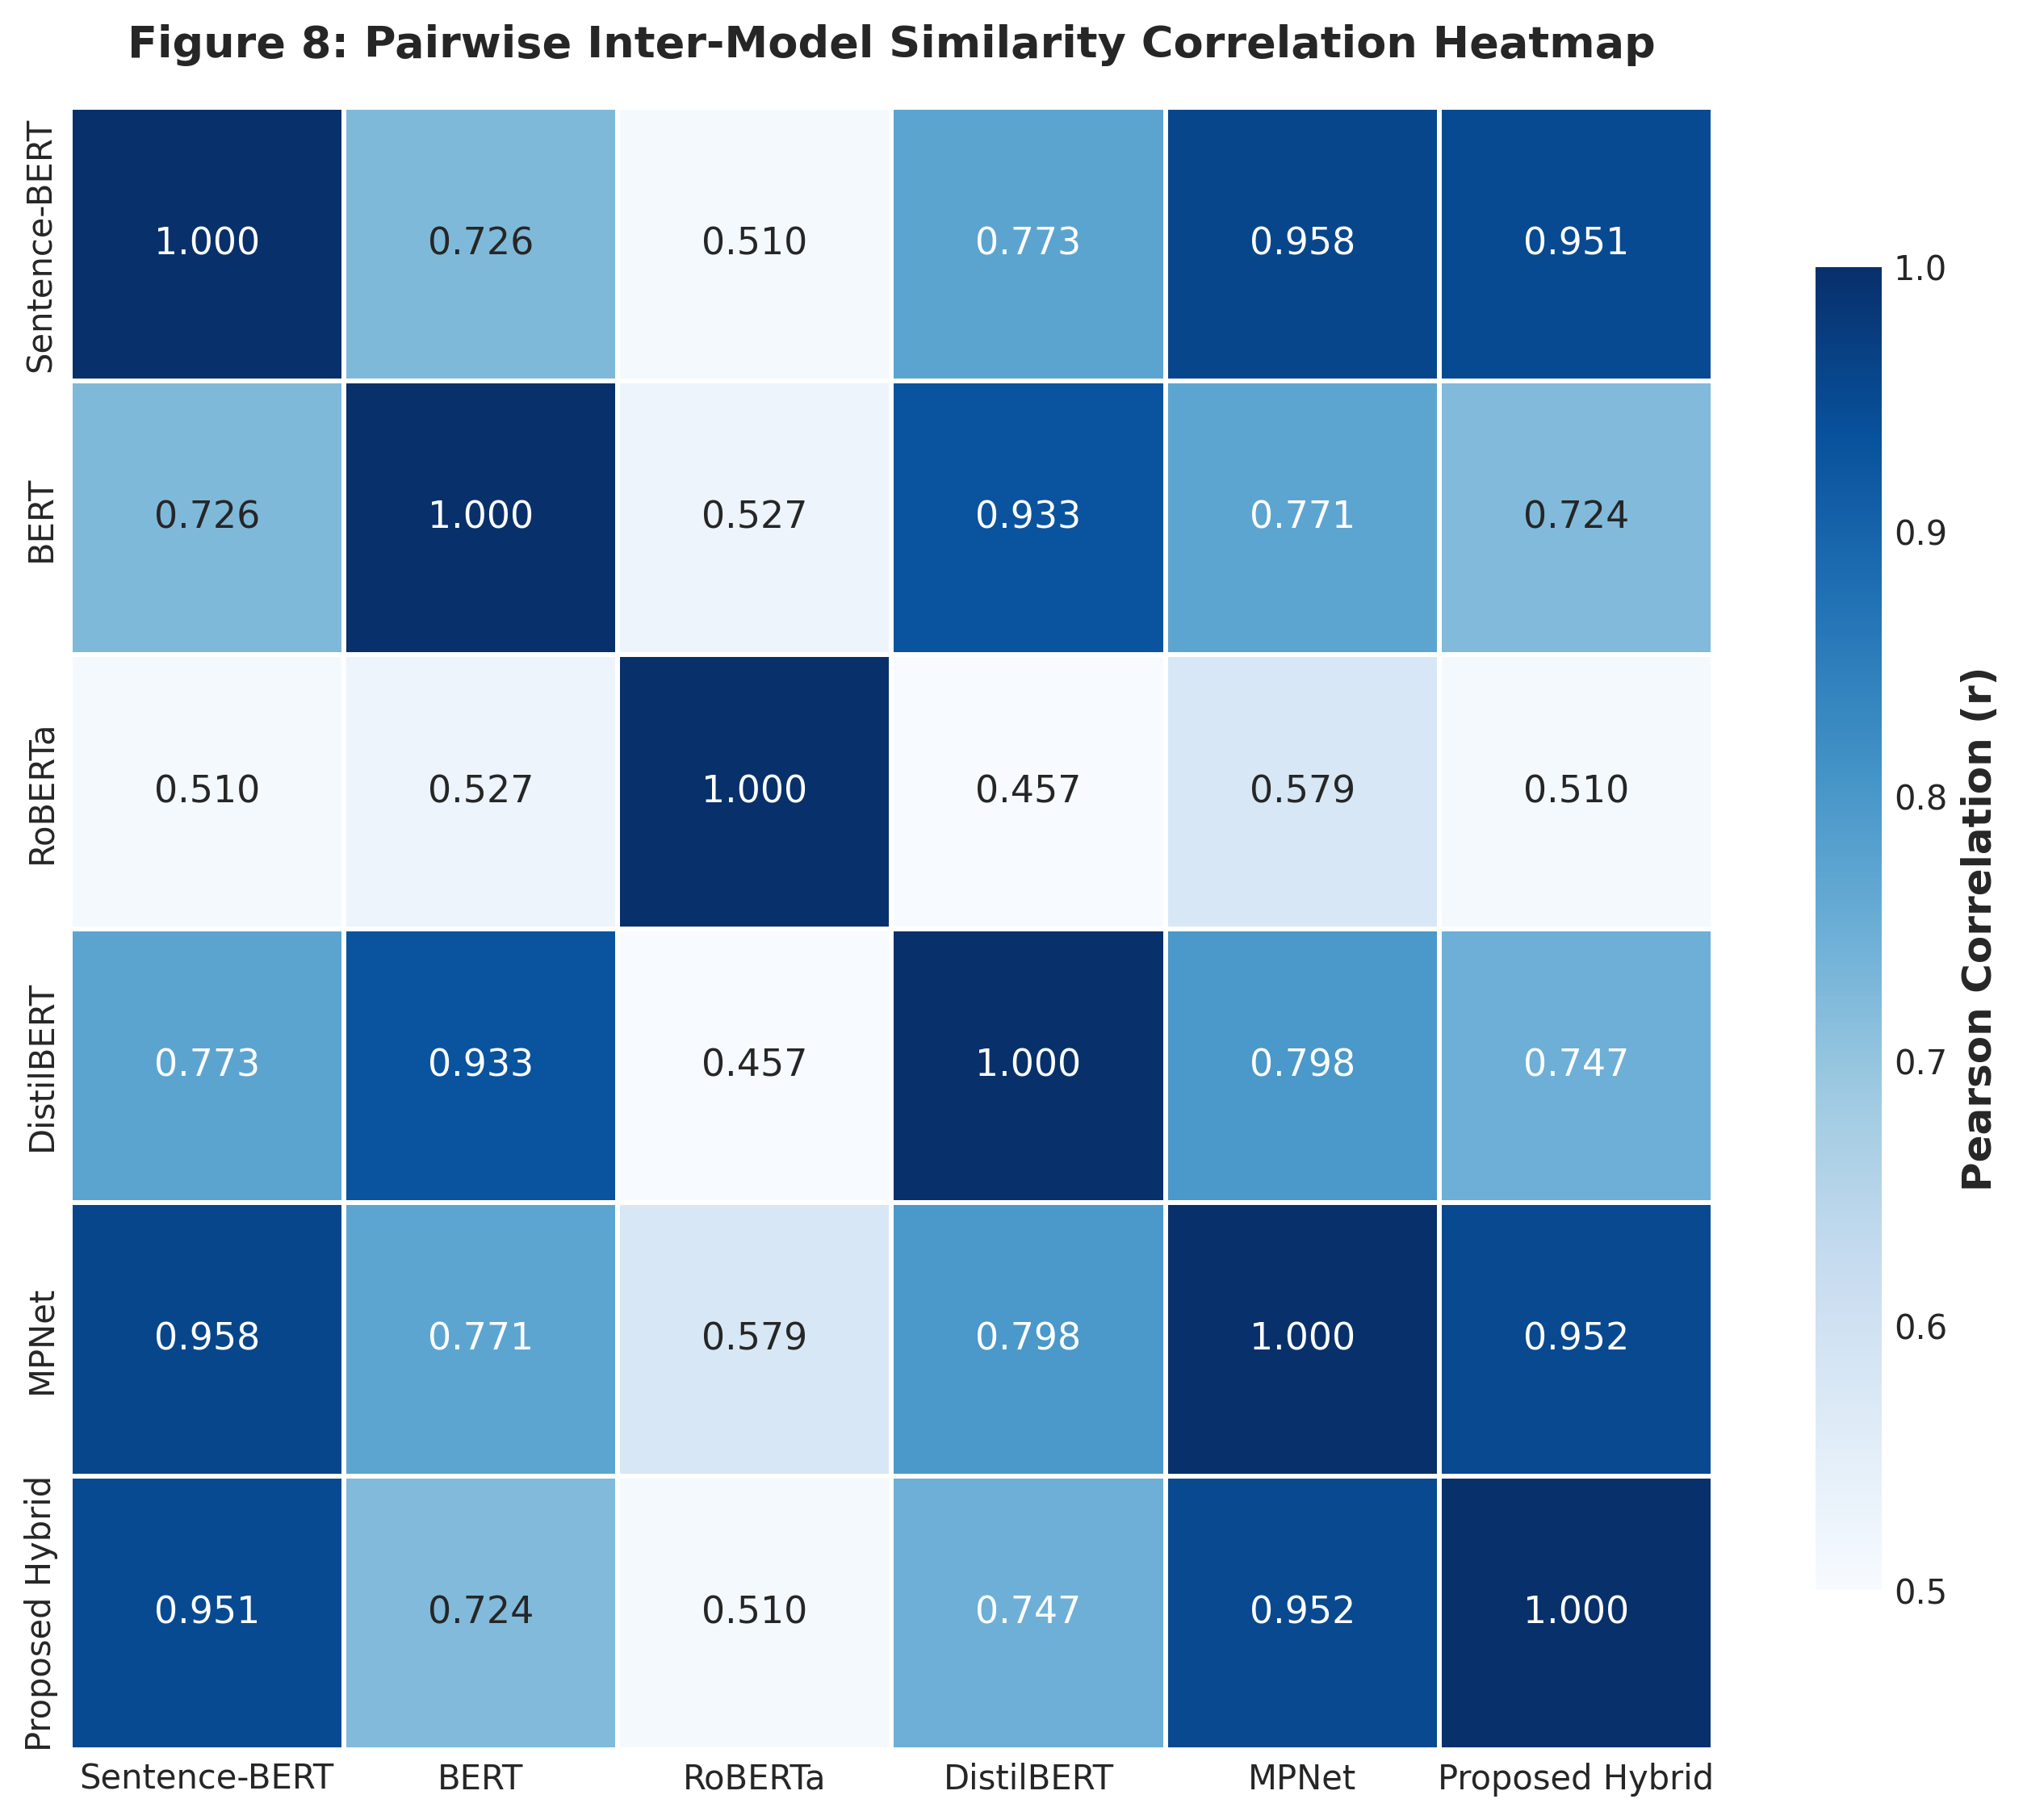

[Figure 8 Generated] Saved to ./figures/


In [21]:
# Step 17: Inter-Model Similarity Correlation Heatmap

model_names_list = list(ALL_MODELS.keys())
score_matrix = np.zeros((len(CALIBRATION_SKILL_PAIRS), len(model_names_list)))

for j, m_name in enumerate(model_names_list):
    score_matrix[:, j] = PR_CURVE_DATA[m_name]["scores"]

df_corr = pd.DataFrame(score_matrix, columns=model_names_list).corr(method="pearson")

plt.figure(figsize=(9, 7.5))
sns.heatmap(
    df_corr, annot=True, fmt=".3f", cmap="Blues", vmin=0.5, vmax=1.0,
    square=True, linewidths=1.0, cbar_kws={"shrink": 0.8, "label": "Pearson Correlation (r)"}
)

plt.title("Figure 8: Pairwise Inter-Model Similarity Correlation Heatmap", pad=15)
plt.tight_layout()
plt.savefig("./figures/fig8_inter_model_correlation_heatmap.png")
plt.show()

print("[Figure 8 Generated] Saved to ./figures/")


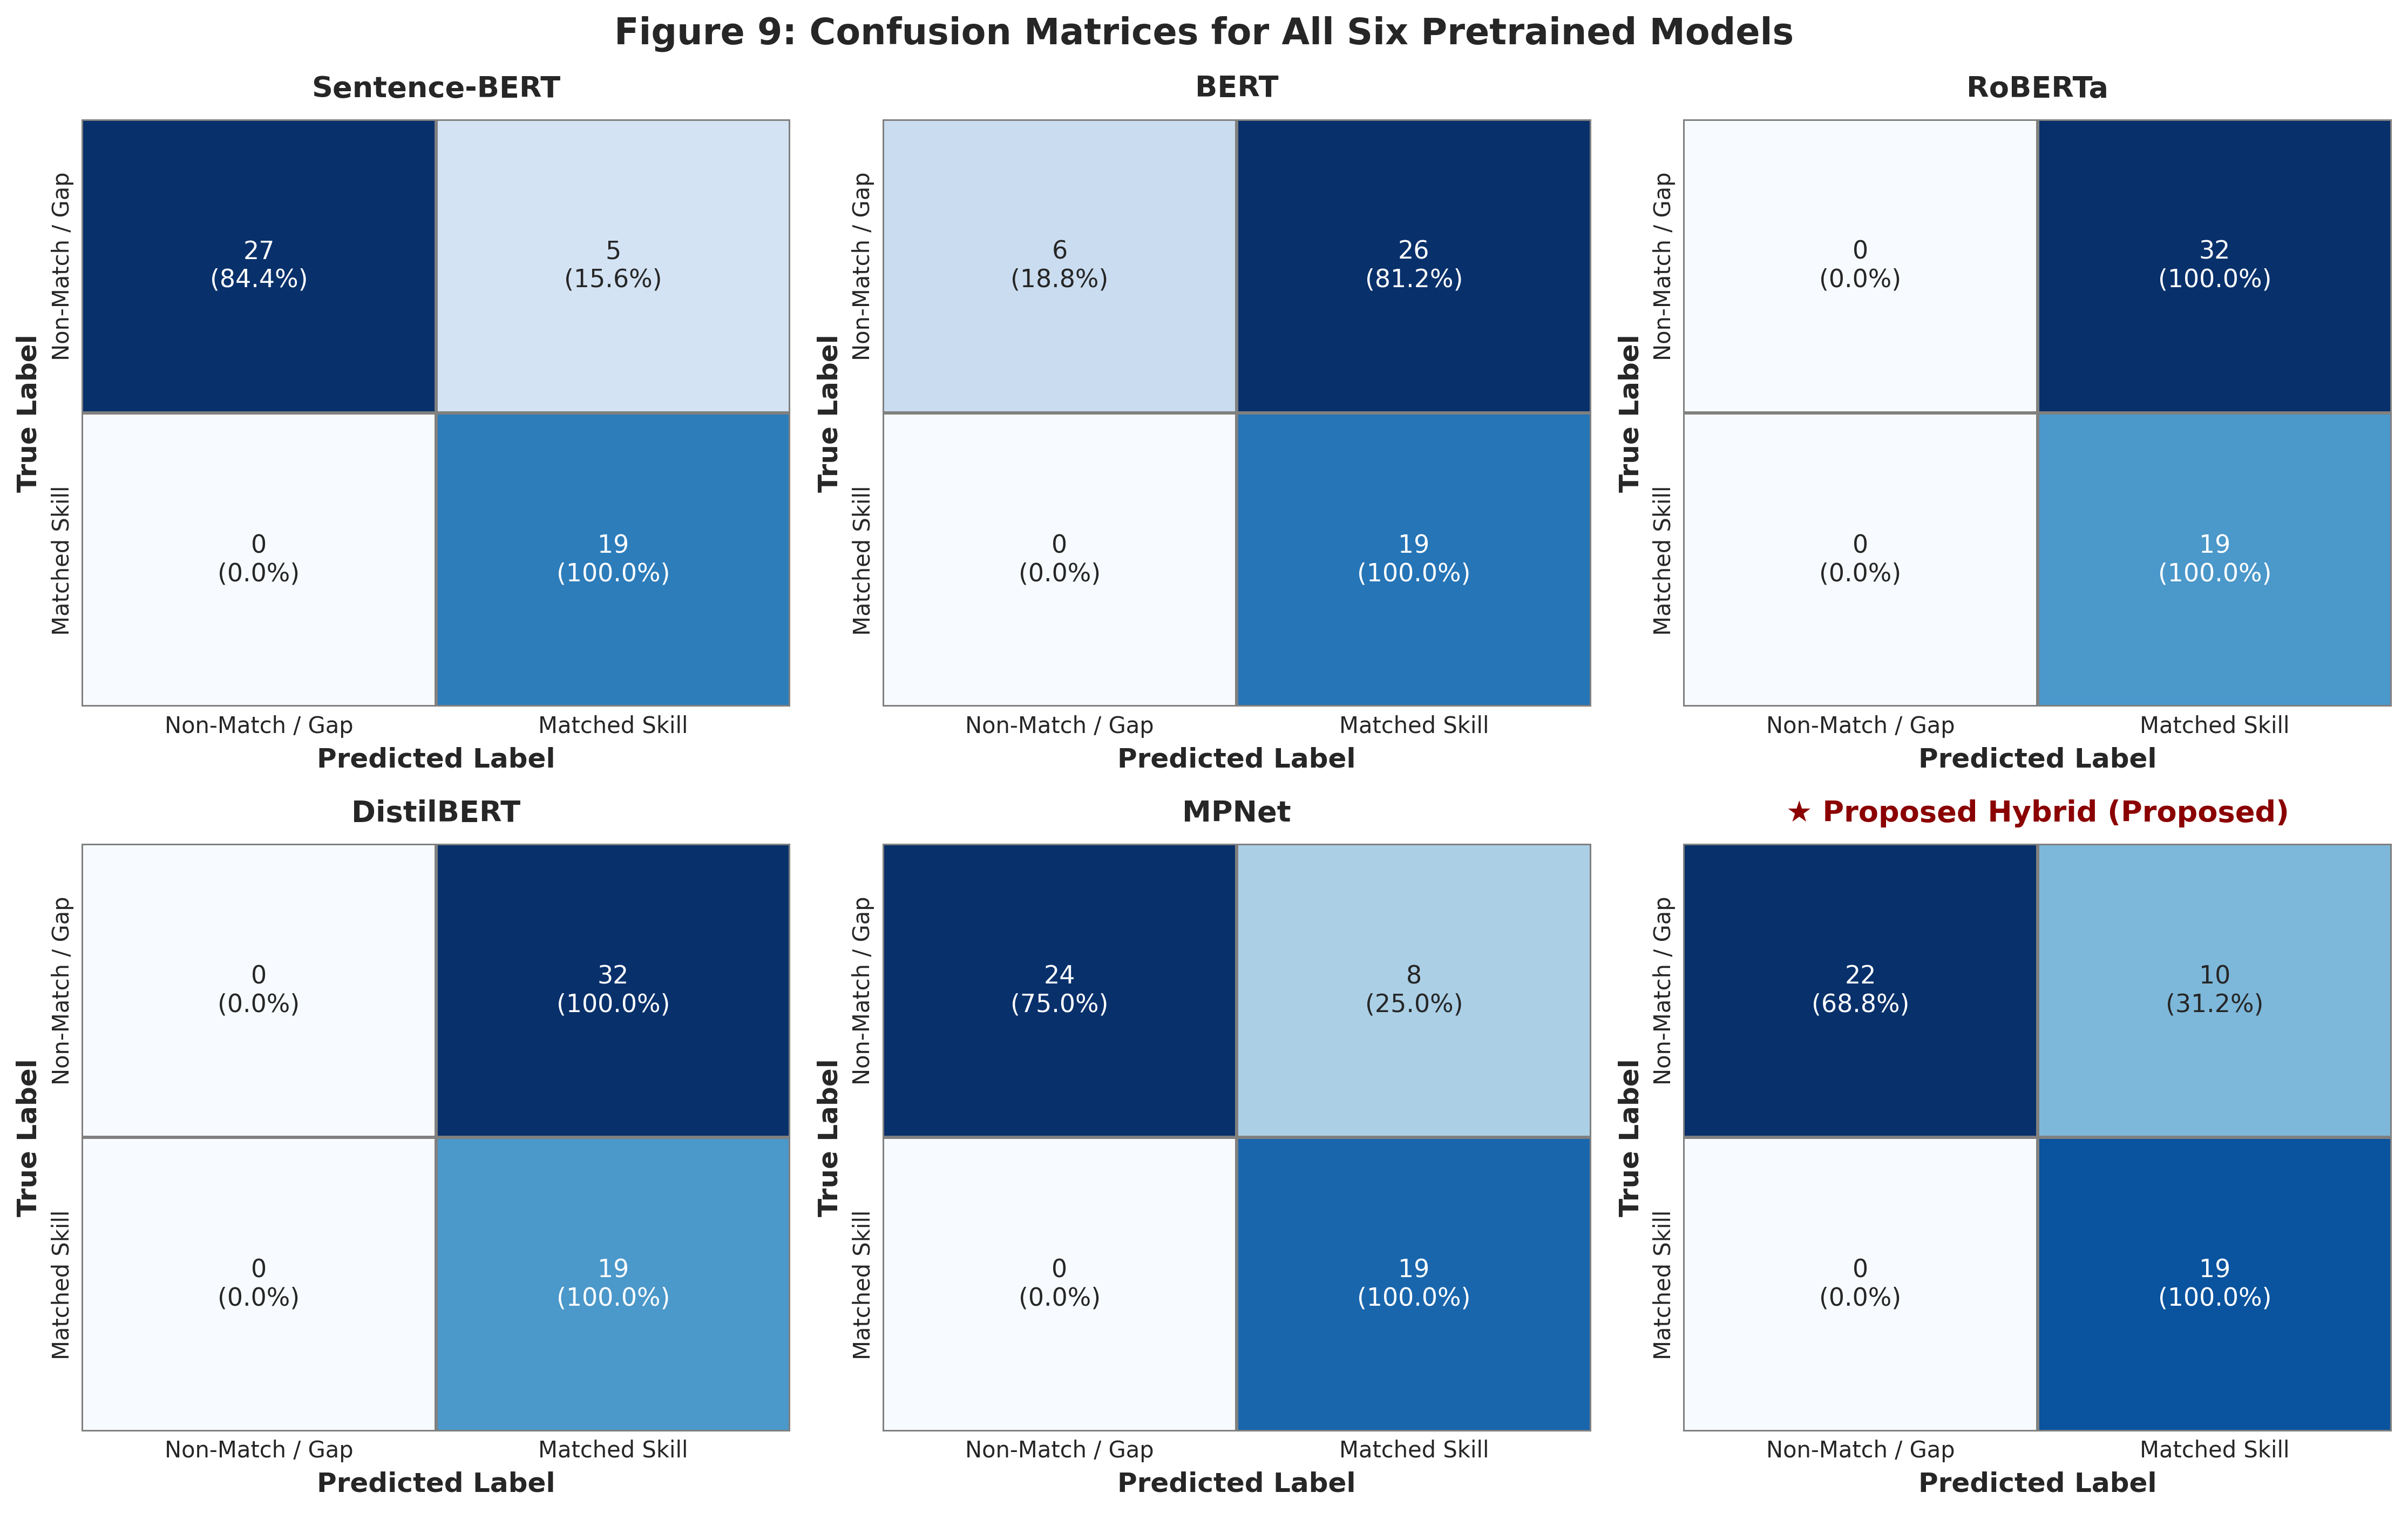

[Figure 9 Generated] Saved to ./figures/


In [18]:
# Step 18: Confusion Matrices for All Six Models (2x3 Subplot Grid)

fig, axes = plt.subplots(2, 3, figsize=(15, 9.5))
axes = axes.flatten()

class_labels = ["Non-Match / Gap", "Matched Skill"]

for i, (m_name, color) in enumerate(MODEL_COLORS.items()):
    ax = axes[i]
    cm = confusion_matrix_data[m_name]
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    annot = np.empty_like(cm, dtype=object)
    for r in range(2):
        for c in range(2):
            annot[r, c] = f"{cm[r, c]}\n({cm_norm[r, c]*100:.1f}%)"

    sns.heatmap(
        cm, annot=annot, fmt="", cmap="Blues", cbar=False,
        xticklabels=class_labels, yticklabels=class_labels, ax=ax,
        linewidths=1.0, linecolor="gray"
    )

    if m_name == "Proposed Hybrid":
        ax.set_title(f"★ {m_name} (Proposed)", fontweight="bold", color="#8b0000", pad=10)
    else:
        ax.set_title(m_name, fontweight="bold", pad=10)

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle("Figure 9: Confusion Matrices for All Six Pretrained Models", fontsize=16, weight="bold", y=0.98)
plt.tight_layout()
plt.savefig("./figures/fig9_confusion_matrices_all_models.png")
plt.show()

print("[Figure 9 Generated] Saved to ./figures/")


---
## Section 9: End-to-End Case Study Demonstration & Career Upskilling Roadmap

In [19]:
# Step 19: End-to-End Case Study & Prioritized Upskilling Roadmap Execution

def run_case_study(candidate_profile: Dict[str, Any], jd_spec: Dict[str, Any], model: ProposedHybridSkillMatcher):
    """Executes end-to-end skill gap audit and constructs an actionable upskilling roadmap."""
    print("="*90)
    print(f"               AI RESUME ANALYZER: END-TO-END AUDIT REPORT")
    print("="*90)
    print(f" Candidate Name : {candidate_profile['name']}")
    print(f" Current Role   : {candidate_profile['title']}")
    print(f" Target Role    : {jd_spec['target_role']}")
    print(f" Domain Cluster : {jd_spec['domain']}")
    print("-"*90)

    # 1. Parse PDF
    pdf_text = ResumePDFParser.extract_text_from_pdf(candidate_profile['pdf_path'])
    sections = ResumePDFParser.segment_sections(pdf_text)

    # 2. Extract Skills with Context
    mentions = skill_extractor.extract_from_resume_sections(sections)
    cand_skills = [m.canonical_skill for m in mentions]
    cand_contexts = [m.context_window for m in mentions]

    print(f"[1] EXTRACTED CANDIDATE SKILLS ({len(cand_skills)} identified):")
    print(f"    {', '.join(cand_skills)}")
    print()

    # 3. Match against Explicit Requirements
    jd_explicit = [esco_engine.canonicalize(s) for s in jd_spec['explicit_skills']]
    opt_th = OPTIMAL_THRESHOLDS["Proposed Hybrid"]

    matched_explicit, explicit_gaps, sim_mat = model.match_skills(
        cand_skills, jd_explicit, threshold=opt_th, candidate_contexts=cand_contexts
    )

    print(f"[2] EXPLICIT REQUIREMENTS AUDIT:")
    print(f"    • Satisfied Skills ({len(matched_explicit)}/{len(jd_explicit)}):")
    for s in matched_explicit:
        j_idx = jd_explicit.index(s)
        best_cand_idx = np.argmax(sim_mat[:, j_idx])
        conf = sim_mat[best_cand_idx, j_idx]
        print(f"       ✓ {s:<26} (Best Match: '{cand_skills[best_cand_idx]}' | Confidence: {conf:.2f})")

    print(f"\n    • EXPLICIT SKILL GAPS ({len(explicit_gaps)} missing hard requirements):")
    for s in explicit_gaps:
        print(f"       ✗ {s:<26} [MANDATORY JOB REQUIREMENT - ABSENT FROM RESUME]")
    print()

    # 4. Implicit Gap Detection
    implicit_prereqs = esco_engine.get_implicit_prerequisites(jd_explicit)
    implicit_targets = [s for s in implicit_prereqs if s not in jd_explicit]

    matched_implicit, implicit_gaps, _ = model.match_skills(
        cand_skills, implicit_targets, threshold=opt_th, candidate_contexts=cand_contexts
    )

    print(f"[3] IMPLICIT SKILL GAPS (Foundational competencies implied by the stack):")
    for s in implicit_gaps:
        triggers = []
        for req in jd_explicit:
            p_list = esco_engine.get_implicit_prerequisites([req])
            if s in p_list:
                triggers.append(req)
        trigger_str = ", ".join(triggers[:2])
        print(f"       ⚠ {s:<26} [Implied by prerequisite dependency on: {trigger_str}]")
    print()

    # 5. Prioritized Upskilling Roadmap
    print("="*90)
    print("                  PERSONALIZED CAREER UPSKILLING ROADMAP")
    print("="*90)
    print(" Phase 1: Close Foundational Implicit Gaps (Prerequisite Bedrock)")
    for i, s in enumerate(implicit_gaps[:3], 1):
        sk_obj = esco_engine.get_skill(s)
        desc = sk_obj.description if sk_obj else "Foundational engineering pattern."
        print(f"   1.{i} Master '{s}' (~2-3 weeks)")
        print(f"       -> Scope: {desc[:85]}...")

    print("\n Phase 2: Master Mandatory Explicit Gaps (Hard Technology Requirements)")
    for i, s in enumerate(explicit_gaps, 1):
        sk_obj = esco_engine.get_skill(s)
        desc = sk_obj.description if sk_obj else "Direct technology stack requirement."
        print(f"   2.{i} Acquire Certification / Build Portfolio in '{s}' (~3-4 weeks)")
        print(f"       -> Scope: {desc[:85]}...")
    print("="*90)

# Execute Case Study for Candidate 1 vs JD 1
run_case_study(RESUME_PROFILES[0], JOB_DESCRIPTIONS[0], model_hybrid)


               AI RESUME ANALYZER: END-TO-END AUDIT REPORT
 Candidate Name : Alex Morgan
 Current Role   : Senior Full-Stack Engineer
 Target Role    : Principal Cloud Architect & Microservices Specialist
 Domain Cluster : Full Stack Cloud
------------------------------------------------------------------------------------------
[1] EXTRACTED CANDIDATE SKILLS (16 identified):
    RESTful API Design, Git Version Control, State Management, TypeScript, JavaScript, Python, SQL, Bash/Shell, React, HTML5/CSS3, Next.js, Node.js, PostgreSQL, Docker, AWS, CI/CD

[2] EXPLICIT REQUIREMENTS AUDIT:
    • Satisfied Skills (5/9):
       ✓ Kubernetes                 (Best Match: 'AWS' | Confidence: 0.55)
       ✓ Docker                     (Best Match: 'AWS' | Confidence: 0.55)
       ✓ Terraform                  (Best Match: 'AWS' | Confidence: 0.56)
       ✓ TypeScript                 (Best Match: 'TypeScript' | Confidence: 1.00)
       ✓ AWS                        (Best Match: 'AWS' | Confidence: 1